# 02 — Exploratory Data Analysis

## Objectives

This notebook explores the current-application data in order to:

- understand feature distributions;
- identify missing values and anomalous observations;
- study associations between predictors and payment difficulty;
- formulate preprocessing and feature-engineering decisions;
- identify potential data-leakage and stability risks.

The analysis is descriptive and predictive, not causal.

## Scope

This notebook focuses on `application_train.csv`.

The auxiliary historical tables, including `bureau`,
`previous_application`, `installments_payments`,
`POS_CASH_balance` and `credit_card_balance`, are outside the scope of
this notebook. They will require separate aggregation before they can
be joined to the application-level modeling table.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42

In [94]:
DATA_DIR = Path("../data/raw")
REPORT_DIR = Path("../reports")
FIGURE_DIR = REPORT_DIR / "figures"
TABLE_DIR = REPORT_DIR / "tables"

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

In [4]:
application = pd.read_csv(
    DATA_DIR / "application_train.csv",
    low_memory=False,
)

application.shape

(307511, 122)

In [7]:
development_df, final_test_df = train_test_split(
    application,
    test_size=0.20,
    stratify=application["TARGET"],
    random_state=RANDOM_STATE,
)
print("Full dataset:", application.shape)
print("Development set:", development_df.shape)
print("Final test set:", final_test_df.shape)

Full dataset: (307511, 122)
Development set: (246008, 122)
Final test set: (61503, 122)


In [8]:
target_rate_comparison = pd.DataFrame(
    {
        "n_rows": [
            len(application),
            len(development_df),
            len(final_test_df),
        ],
        "target_rate": [
            application["TARGET"].mean(),
            development_df["TARGET"].mean(),
            final_test_df["TARGET"].mean(),
        ],
    },
    index=["full", "development", "final_test"],
)

target_rate_comparison

,n_rows,target_rate
full,307511,0.081
development,246008,0.081
final_test,61503,0.081


In [9]:
eda_df = development_df.copy()

## Data partition

A stratified 20% final test set was isolated before target-based EDA.
All exploratory decisions are based only on the development set.

The final test set will remain untouched until the model,
hyperparameters and decision threshold have been selected.

## 1. Target distribution

In [10]:
target_summary = (
    eda_df["TARGET"]
    .value_counts()
    .sort_index()
    .to_frame("count")
)

target_summary["percentage"] = (
    target_summary["count"] / len(eda_df) * 100
)

target_summary.index = [
    "No payment difficulty",
    "Payment difficulty",
]

target_summary

,count,percentage
No payment difficulty,226148,91.927
Payment difficulty,19860,8.073


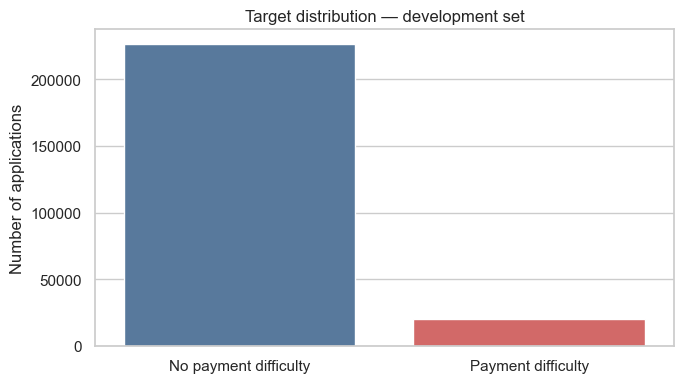

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.countplot(
    data=eda_df,
    x="TARGET",
    hue="TARGET",
    palette={0: "#4C78A8", 1: "#E45756"},
    legend=False,
    ax=ax,
)

ax.set_title("Target distribution — development set")
ax.set_xlabel("")
ax.set_ylabel("Number of applications")
ax.set_xticks([0, 1])
ax.set_xticklabels(
    ["No payment difficulty", "Payment difficulty"]
)

plt.tight_layout()
plt.show()

In [12]:
n_negative = (eda_df["TARGET"] == 0).sum()
n_positive = (eda_df["TARGET"] == 1).sum()

imbalance_ratio = n_negative / n_positive

print(f"Negative observations: {n_negative:,}")
print(f"Positive observations: {n_positive:,}")
print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

Negative observations: 226,148
Positive observations: 19,860
Imbalance ratio: 11.39:1


Approximately 8.1% of applications in the development set are associated
with payment difficulty. There are approximately 11 non-difficulty cases
for each difficulty case.

Consequently, accuracy is not an appropriate primary evaluation metric.
The modeling phase should emphasize ROC-AUC, PR-AUC, recall at selected
operating thresholds and probability calibration. Stratification must be
preserved during data splitting and cross-validation.

## 2. Missing-value analysis

In [13]:
missing_summary = pd.DataFrame(
    {
        "missing_count": eda_df.isna().sum(),
        "missing_pct": eda_df.isna().mean() * 100,
        "dtype": eda_df.dtypes.astype(str),
    }
).sort_values("missing_pct", ascending=False)

missing_summary.query("missing_count > 0").head(20)

,missing_count,missing_pct,dtype
COMMONAREA_MEDI,171811,69.840,float64
COMMONAREA_AVG,171811,69.840,float64
COMMONAREA_MODE,171811,69.840,float64
NONLIVINGAPARTMENTS_MODE,170729,69.400,float64
NONLIVINGAPARTMENTS_AVG,170729,69.400,float64
NONLIVINGAPARTMENTS_MEDI,170729,69.400,float64
FONDKAPREMONT_MODE,168215,68.378,object
LIVINGAPARTMENTS_MODE,168119,68.339,float64
LIVINGAPARTMENTS_AVG,168119,68.339,float64
LIVINGAPARTMENTS_MEDI,168119,68.339,float64


In [21]:
predictor_columns = [
    column
    for column in eda_df.columns
    if column not in ["SK_ID_CURR", "TARGET"]
]

row_missing_count = eda_df[predictor_columns].isna().sum(axis=1)

row_missing_pct = (
    row_missing_count
    / len(predictor_columns)
    * 100
)

row_missing_count.describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count   246,008.000
mean         29.749
std          20.921
min           0.000
25%           5.000
50%          36.000
75%          49.000
90%          50.000
95%          55.000
99%          57.000
max          61.000
dtype: float64

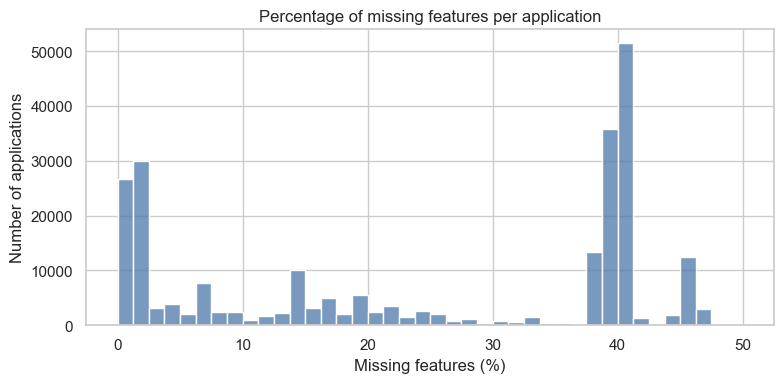

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(
    row_missing_pct,
    bins=40,
    color="#4C78A8",
    ax=ax,
)

ax.set_title("Percentage of missing features per application")
ax.set_xlabel("Missing features (%)")
ax.set_ylabel("Number of applications")

plt.tight_layout()
plt.show()

In [16]:
missing_by_target = pd.DataFrame(
    {
        "missing_pct_target_0": (
            eda_df.loc[eda_df["TARGET"] == 0]
            .isna()
            .mean()
            .mul(100)
        ),
        "missing_pct_target_1": (
            eda_df.loc[eda_df["TARGET"] == 1]
            .isna()
            .mean()
            .mul(100)
        ),
    }
)

missing_by_target["absolute_difference"] = (
    missing_by_target["missing_pct_target_1"]
    - missing_by_target["missing_pct_target_0"]
).abs()

missing_by_target = missing_by_target.sort_values(
    "absolute_difference",
    ascending=False,
)

missing_by_target.head(20)

,missing_pct_target_0,missing_pct_target_1,absolute_difference
EMERGENCYSTATE_MODE,46.781,54.310,7.529
TOTALAREA_MODE,47.649,55.136,7.487
FLOORSMAX_AVG,49.113,56.536,7.422
FLOORSMAX_MEDI,49.113,56.536,7.422
FLOORSMAX_MODE,49.113,56.536,7.422
ENTRANCES_MODE,49.717,57.110,7.393
ENTRANCES_AVG,49.717,57.110,7.393
ENTRANCES_MEDI,49.717,57.110,7.393
YEARS_BEGINEXPLUATATION_AVG,48.164,55.524,7.360
YEARS_BEGINEXPLUATATION_MEDI,48.164,55.524,7.360


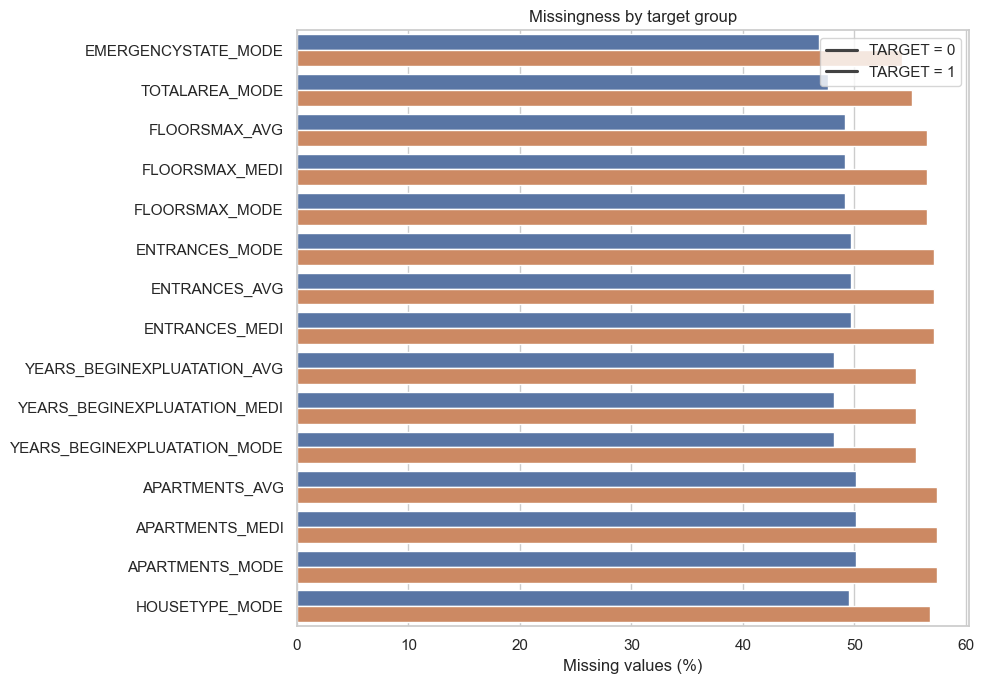

In [17]:
top_missing_target = (
    missing_by_target
    .head(15)
    .reset_index()
    .rename(columns={"index": "feature"})
)

plot_data = top_missing_target.melt(
    id_vars="feature",
    value_vars=[
        "missing_pct_target_0",
        "missing_pct_target_1",
    ],
    var_name="target_group",
    value_name="missing_pct",
)

fig, ax = plt.subplots(figsize=(10, 7))

sns.barplot(
    data=plot_data,
    y="feature",
    x="missing_pct",
    hue="target_group",
    ax=ax,
)

ax.set_title("Missingness by target group")
ax.set_xlabel("Missing values (%)")
ax.set_ylabel("")
ax.legend(
    title="",
    labels=["TARGET = 0", "TARGET = 1"],
)

plt.tight_layout()
plt.show()

In [ ]:
def missing_target_analysis(
    df: pd.DataFrame,
    features: list[str],
    target: str = "TARGET",
    min_group_count: int = 500,
) -> pd.DataFrame:
    """Compare target rates for missing and observed feature values."""
    records = []

    for feature in features:
        missing_mask = df[feature].isna()

        missing_count = int(missing_mask.sum())
        observed_count = int((~missing_mask).sum())

        if missing_count == 0:
            continue

        target_rate_when_missing = df.loc[
            missing_mask,
            target,
        ].mean()

        target_rate_when_observed = df.loc[
            ~missing_mask,
            target,
        ].mean()

        target_rate_difference = (
            target_rate_when_missing
            - target_rate_when_observed
        )

        records.append(
            {
                "feature": feature,
                "missing_count": missing_count,
                "observed_count": observed_count,
                "missing_pct": (
                    missing_count / len(df) * 100
                ),
                "target_rate_when_missing": (
                    target_rate_when_missing
                ),
                "target_rate_when_observed": (
                    target_rate_when_observed
                ),
                "target_rate_difference": (
                    target_rate_difference
                ),
                "absolute_target_rate_difference": abs(
                    target_rate_difference
                ),
                "reliable_for_comparison": (
                    missing_count >= min_group_count
                    and observed_count >= min_group_count
                ),
            }
        )

    return (
        pd.DataFrame(records)
        .sort_values(
            "absolute_target_rate_difference",
            ascending=False,
        )
        .reset_index(drop=True)
    )


missing_target_report = missing_target_analysis(
    df=eda_df,
    features=predictor_columns,
)

reliable_missing_report = (
    missing_target_report
    .loc[
        missing_target_report[
            "reliable_for_comparison"
        ]
    ]
    .reset_index(drop=True)
)

reliable_missing_report.head(20)

,feature,missing_count,observed_count,missing_pct,target_rate_when_missing,target_rate_when_observed,target_rate_difference,absolute_target_rate_difference,reliable_for_comparison
0,OBS_30_CNT_SOCIAL_CIRCLE,811,245197,0.330,0.039,0.081,-0.041,0.041,True
1,DEF_60_CNT_SOCIAL_CIRCLE,811,245197,0.330,0.039,0.081,-0.041,0.041,True
2,OBS_60_CNT_SOCIAL_CIRCLE,811,245197,0.330,0.039,0.081,-0.041,0.041,True
3,DEF_30_CNT_SOCIAL_CIRCLE,811,245197,0.330,0.039,0.081,-0.041,0.041,True
4,AMT_REQ_CREDIT_BUREAU_QRT,33244,212764,13.513,0.103,0.077,0.026,0.026,True
5,AMT_REQ_CREDIT_BUREAU_MON,33244,212764,13.513,0.103,0.077,0.026,0.026,True
6,AMT_REQ_CREDIT_BUREAU_WEEK,33244,212764,13.513,0.103,0.077,0.026,0.026,True
7,AMT_REQ_CREDIT_BUREAU_DAY,33244,212764,13.513,0.103,0.077,0.026,0.026,True
8,AMT_REQ_CREDIT_BUREAU_HOUR,33244,212764,13.513,0.103,0.077,0.026,0.026,True
9,AMT_REQ_CREDIT_BUREAU_YEAR,33244,212764,13.513,0.103,0.077,0.026,0.026,True


Target-rate differences based on very small missing groups are unstable.
Therefore, comparisons are displayed only when both the missing and
observed groups contain at least 500 applications.

## Missing-value findings

- Missingness is particularly concentrated in housing-related variables.
  For example, the three `COMMONAREA_*` variables are missing for approximately
  69.8% of applicants, while the `NONLIVINGAPARTMENTS_*` variables are missing
  for approximately 69.4%.

- Missingness varies substantially across applicants. The median applicant has
  36 missing predictors out of 120, while the maximum is 61 missing predictors.

- The six `AMT_REQ_CREDIT_BUREAU_*` variables are missing for approximately
  13.5% of applicants. Their payment-difficulty rate is approximately 10.3%
  when missing, compared with 7.7% when observed, a difference of about
  2.6 percentage points.

- `OCCUPATION_TYPE` is missing for approximately 31.3% of applicants.
  Interestingly, the target rate is lower when it is missing (6.5%) than when
  it is observed (8.8%). Missingness may therefore reflect applicant profiles
  such as employment or pension status rather than random data loss.

- Several housing variables show a payment-difficulty rate of approximately
  9.2% when missing, compared with approximately 7.0% when observed.
  The availability of housing information may therefore contain predictive
  information.

- Missing indicators and imputation strategies should be evaluated inside the
  training pipeline. No feature should be removed solely because of its
  missing-value rate.

## 3. Numerical-feature analysis

In [23]:
numerical_eda_df = eda_df.copy()
numerical_eda_df["AGE_YEARS"] = (
    -numerical_eda_df["DAYS_BIRTH"] / 365.25
)

numerical_eda_df["DAYS_EMPLOYED_ANOMALOUS"] = (
    numerical_eda_df["DAYS_EMPLOYED"] == 365243
).astype("int8")

numerical_eda_df["EMPLOYMENT_YEARS"] = (
    numerical_eda_df["DAYS_EMPLOYED"]
    .replace(365243, np.nan)
    .mul(-1)
    .div(365.25)
)

numerical_eda_df["REGISTRATION_YEARS"] = (
    -numerical_eda_df["DAYS_REGISTRATION"] / 365.25
)

numerical_eda_df["ID_PUBLISH_YEARS"] = (
    -numerical_eda_df["DAYS_ID_PUBLISH"] / 365.25
)

In [24]:
numerical_eda_df[
    [
        "AGE_YEARS",
        "EMPLOYMENT_YEARS",
        "DAYS_EMPLOYED_ANOMALOUS",
        "REGISTRATION_YEARS",
        "ID_PUBLISH_YEARS",
    ]
].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
AGE_YEARS,"246,008.000",43.886,11.945,20.504,22.615,25.739,33.952,43.105,53.862,63.507,66.836,69.073
EMPLOYMENT_YEARS,"201,865.000",6.530,6.406,-0.000,0.304,0.564,2.097,4.512,8.695,19.975,31.044,49.040
DAYS_EMPLOYED_ANOMALOUS,"246,008.000",0.179,0.384,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,1.000
REGISTRATION_YEARS,"246,008.000",13.661,9.650,-0.000,0.140,0.906,5.517,12.334,20.479,31.288,38.064,67.548
ID_PUBLISH_YEARS,"246,008.000",8.198,4.129,0.000,0.170,1.029,4.709,8.912,11.767,13.530,14.913,19.704


In [25]:
print(
    "Age outside [18, 100]:",
    (~numerical_eda_df["AGE_YEARS"].between(18, 100)).sum(),
)

print(
    "Negative employment duration:",
    (numerical_eda_df["EMPLOYMENT_YEARS"] < 0).sum(),
)

print(
    "Employment duration greater than age:",
    (
        numerical_eda_df["EMPLOYMENT_YEARS"]
        > numerical_eda_df["AGE_YEARS"]
    ).sum(),
)

Age outside [18, 100]: 0
Negative employment duration: 0
Employment duration greater than age: 0


In [93]:
employment_start_age = (
    numerical_eda_df["AGE_YEARS"]
    - numerical_eda_df["EMPLOYMENT_YEARS"]
)

employment_start_age.describe(
    percentiles=[
        0.01,
        0.05,
        0.50,
        0.95,
        0.99,
    ]
)

count   201,865.000
mean         33.900
std           9.819
min          17.916
1%           18.513
5%           20.252
50%          32.723
95%          51.532
99%          57.665
max          68.164
dtype: float64

In [28]:
key_numerical_features = [
    "AGE_YEARS",
    "EMPLOYMENT_YEARS",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
]

numerical_eda_df[key_numerical_features].describe(
    percentiles=[
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99,
    ]
).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
AGE_YEARS,"246,008.000",43.886,11.945,20.504,22.615,25.739,33.952,43.105,53.862,63.507,66.836,69.073
EMPLOYMENT_YEARS,"201,865.000",6.530,6.406,-0.000,0.304,0.564,2.097,4.512,8.695,19.975,31.044,49.040
AMT_INCOME_TOTAL,"246,008.000","168,853.181","258,960.632","25,650.000","45,000.000","67,500.000","112,500.000","147,600.000","202,500.000","337,500.000","472,500.000","117,000,000.000"
AMT_CREDIT,"246,008.000","599,338.249","402,725.773","45,000.000","76,410.000","135,000.000","270,000.000","514,777.500","808,650.000","1,350,000.000","1,862,802.000","4,050,000.000"
AMT_ANNUITY,"245,998.000","27,108.090","14,520.904","1,615.500","6,187.500","9,000.000","16,510.500","24,903.000","34,596.000","53,325.000","70,033.500","258,025.500"
AMT_GOODS_PRICE,"245,787.000","538,652.980","369,595.050","40,500.000","67,500.000","135,000.000","238,500.000","450,000.000","679,500.000","1,305,000.000","1,800,000.000","4,050,000.000"
EXT_SOURCE_1,"107,413.000",0.502,0.211,0.015,0.084,0.157,0.333,0.505,0.675,0.832,0.890,0.952
EXT_SOURCE_2,"245,477.000",0.514,0.191,0.000,0.029,0.132,0.392,0.566,0.664,0.748,0.783,0.855
EXT_SOURCE_3,"197,203.000",0.511,0.195,0.001,0.065,0.155,0.371,0.535,0.669,0.786,0.834,0.896


In [29]:
def numerical_feature_summary(
    df: pd.DataFrame,
    features: list[str],
) -> pd.DataFrame:
    records = []

    for feature in features:
        series = df[feature]

        records.append(
            {
                "feature": feature,
                "missing_pct": series.isna().mean() * 100,
                "n_unique": series.nunique(),
                "mean": series.mean(),
                "median": series.median(),
                "std": series.std(),
                "min": series.min(),
                "p01": series.quantile(0.01),
                "p99": series.quantile(0.99),
                "max": series.max(),
                "skewness": series.skew(),
            }
        )

    return pd.DataFrame(records).set_index("feature")


numerical_summary = numerical_feature_summary(
    numerical_eda_df,
    key_numerical_features,
)

numerical_summary

,missing_pct,n_unique,mean,median,std,min,p01,p99,max,skewness
feature,,,,,,,,,,
AGE_YEARS,0.000,17417,43.886,43.105,11.945,20.504,22.615,66.836,69.073,0.116
EMPLOYMENT_YEARS,17.944,12103,6.530,4.512,6.406,-0.000,0.304,31.044,49.040,1.965
AMT_INCOME_TOTAL,0.000,2168,"168,853.181","147,600.000","258,960.632","25,650.000","45,000.000","472,500.000","117,000,000.000",375.128
AMT_CREDIT,0.000,5274,"599,338.249","514,777.500","402,725.773","45,000.000","76,410.000","1,862,802.000","4,050,000.000",1.234
AMT_ANNUITY,0.004,13135,"27,108.090","24,903.000","14,520.904","1,615.500","6,187.500","70,033.500","258,025.500",1.604
AMT_GOODS_PRICE,0.090,884,"538,652.980","450,000.000","369,595.050","40,500.000","67,500.000","1,800,000.000","4,050,000.000",1.348
EXT_SOURCE_1,56.338,94564,0.502,0.505,0.211,0.015,0.084,0.890,0.952,-0.066
EXT_SOURCE_2,0.216,108825,0.514,0.566,0.191,0.000,0.029,0.783,0.855,-0.794
EXT_SOURCE_3,19.839,806,0.511,0.535,0.195,0.001,0.065,0.834,0.896,-0.410


In [30]:
def plot_clipped_distribution(
    df: pd.DataFrame,
    feature: str,
    lower_quantile: float = 0.01,
    upper_quantile: float = 0.99,
) -> None:
    series = df[feature].dropna()

    lower = series.quantile(lower_quantile)
    upper = series.quantile(upper_quantile)

    plot_series = series.clip(lower=lower, upper=upper)

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 4),
        gridspec_kw={"width_ratios": [3, 1]},
    )

    sns.histplot(
        plot_series,
        bins=50,
        color="#4C78A8",
        ax=axes[0],
    )

    sns.boxplot(
        y=plot_series,
        color="#72B7B2",
        ax=axes[1],
    )

    axes[0].set_title(
        f"{feature} distribution\n"
        f"display clipped at p1–p99"
    )
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel("Number of applications")

    axes[1].set_title("Boxplot")
    axes[1].set_ylabel(feature)

    plt.tight_layout()
    plt.show()

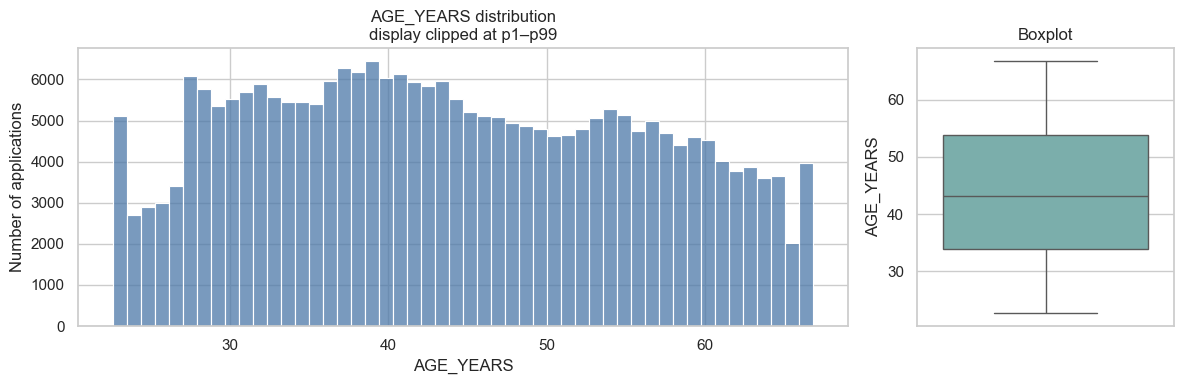

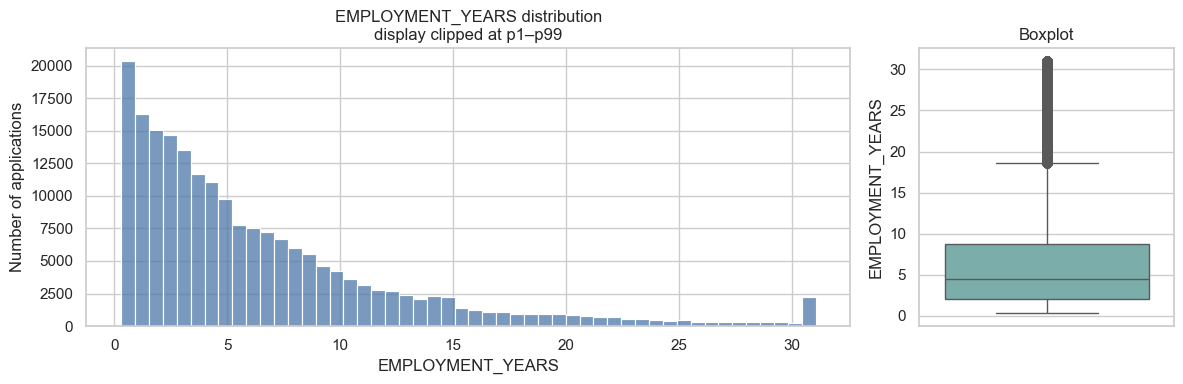

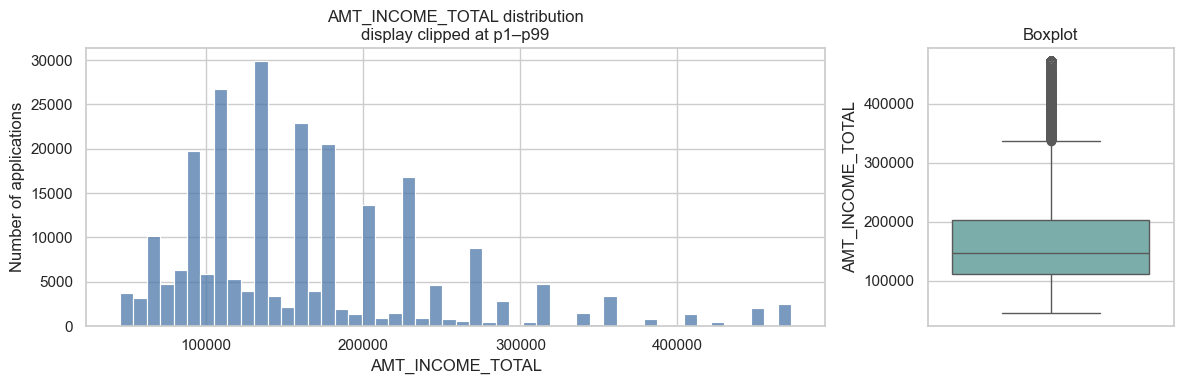

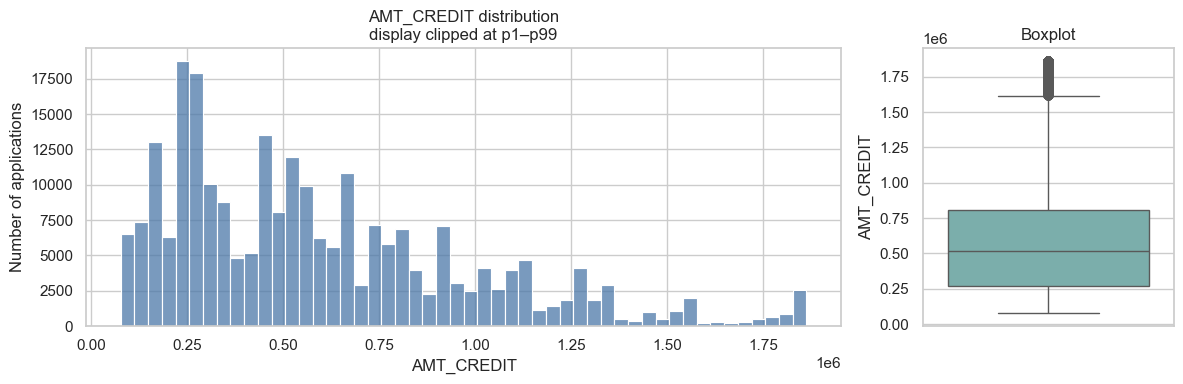

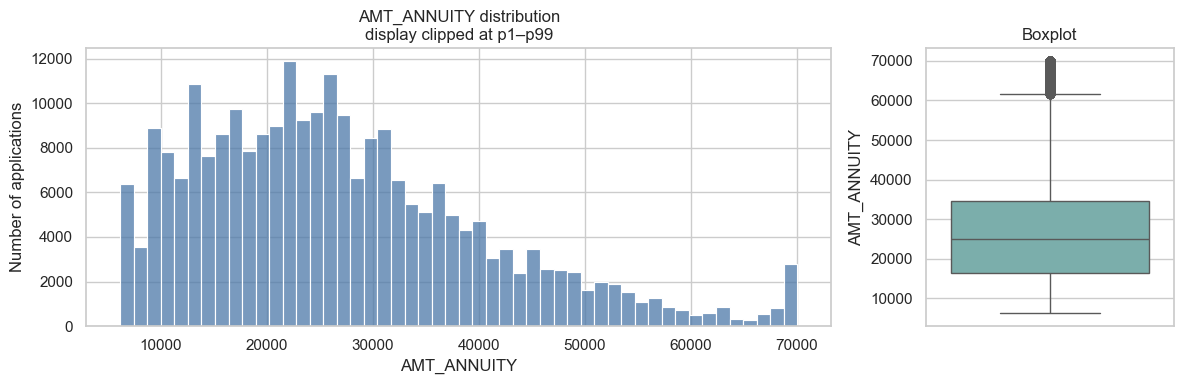

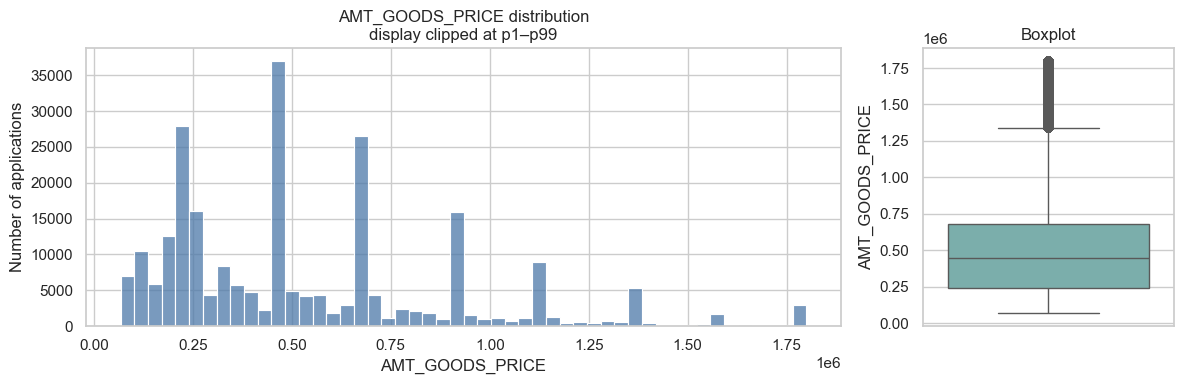

In [31]:
for feature in [
    "AGE_YEARS",
    "EMPLOYMENT_YEARS",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
]:
    plot_clipped_distribution(
        numerical_eda_df,
        feature,
    )

In [32]:
amount_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
]

extreme_value_summary = []

for feature in amount_features:
    series = numerical_eda_df[feature]

    extreme_value_summary.append(
        {
            "feature": feature,
            "p95": series.quantile(0.95),
            "p99": series.quantile(0.99),
            "p999": series.quantile(0.999),
            "max": series.max(),
            "max_over_p99": (
                series.max() / series.quantile(0.99)
            ),
        }
    )

extreme_value_summary = pd.DataFrame(
    extreme_value_summary
).set_index("feature")

extreme_value_summary

,p95,p99,p999,max,max_over_p99
feature,,,,,
AMT_INCOME_TOTAL,"337,500.000","472,500.000","900,000.000","117,000,000.000",247.619
AMT_CREDIT,"1,350,000.000","1,862,802.000","2,517,300.000","4,050,000.000",2.174
AMT_ANNUITY,"53,325.000","70,033.500","111,001.770","258,025.500",3.684
AMT_GOODS_PRICE,"1,305,000.000","1,800,000.000","2,250,000.000","4,050,000.000",2.250


In [33]:
numerical_eda_df[
    [
        "SK_ID_CURR",
        "TARGET",
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "AMT_ANNUITY",
        "AMT_GOODS_PRICE",
        "NAME_INCOME_TYPE",
        "OCCUPATION_TYPE",
    ]
].nlargest(
    15,
    "AMT_INCOME_TOTAL",
)

,SK_ID_CURR,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,OCCUPATION_TYPE
12840,114967,1,"117,000,000.000","562,491.000","26,194.500","454,500.000",Working,Laborers
203693,336147,0,"18,000,090.000","675,000.000","69,295.500","675,000.000",Commercial associate,NaN
77768,190160,0,"9,000,000.000","1,431,531.000","132,601.500","1,377,000.000",Working,Managers
131127,252084,0,"6,750,000.000","790,830.000","52,978.500","675,000.000",Working,Laborers
204564,337151,0,"4,500,000.000","450,000.000","47,749.500","450,000.000",Working,Managers
103006,219563,0,"4,500,000.000","2,250,000.000","225,000.000","2,250,000.000",Working,Managers
181698,310601,0,"3,950,059.500","675,000.000","66,217.500","675,000.000",Commercial associate,Managers
49645,157471,0,"3,600,000.000","953,460.000","68,791.500","900,000.000",Commercial associate,NaN
284311,429258,0,"3,600,000.000","1,113,840.000","44,302.500","900,000.000",Working,Core staff
82846,196091,0,"3,375,000.000","900,000.000","40,801.500","900,000.000",Working,Core staff


In [34]:
def summarize_by_target(
    df: pd.DataFrame,
    features: list[str],
    target: str = "TARGET",
) -> pd.DataFrame:
    records = []

    for feature in features:
        for target_value in [0, 1]:
            series = df.loc[
                df[target] == target_value,
                feature,
            ]

            records.append(
                {
                    "feature": feature,
                    "target": target_value,
                    "count_observed": series.notna().sum(),
                    "missing_pct": series.isna().mean() * 100,
                    "mean": series.mean(),
                    "median": series.median(),
                    "p25": series.quantile(0.25),
                    "p75": series.quantile(0.75),
                }
            )

    return pd.DataFrame(records)


numerical_by_target = summarize_by_target(
    numerical_eda_df,
    key_numerical_features,
)

numerical_by_target

,feature,target,count_observed,missing_pct,mean,median,p25,p75
0,AGE_YEARS,0,226148,0.000,44.168,43.461,34.294,54.177
1,AGE_YEARS,1,19860,0.000,40.683,39.040,31.173,49.317
2,EMPLOYMENT_YEARS,0,184375,18.472,6.678,4.630,2.160,8.909
3,EMPLOYMENT_YEARS,1,17490,11.934,4.967,3.362,1.613,6.554
4,AMT_INCOME_TOTAL,0,226148,0.000,"169,062.453","148,500.000","112,500.000","202,500.000"
5,AMT_INCOME_TOTAL,1,19860,0.000,"166,470.173","135,000.000","112,500.000","202,500.000"
6,AMT_CREDIT,0,226148,0.000,"603,014.441","518,562.000","270,000.000","810,000.000"
7,AMT_CREDIT,1,19860,0.000,"557,477.051","495,216.000","284,400.000","733,315.500"
8,AMT_ANNUITY,0,226138,0.004,"27,162.889","24,871.500","16,456.500","34,749.000"
9,AMT_ANNUITY,1,19860,0.000,"26,484.114","25,200.000","17,358.750","32,998.500"


In [35]:
median_by_target = numerical_by_target.pivot(
    index="feature",
    columns="target",
    values="median",
).rename(
    columns={
        0: "median_target_0",
        1: "median_target_1",
    }
)

median_by_target["relative_median_difference_pct"] = (
    (
        median_by_target["median_target_1"]
        - median_by_target["median_target_0"]
    )
    / median_by_target["median_target_0"].abs()
    * 100
)

median_by_target

target,median_target_0,median_target_1,relative_median_difference_pct
feature,,,
AGE_YEARS,43.461,39.040,-10.171
AMT_ANNUITY,"24,871.500","25,200.000",1.321
AMT_CREDIT,"518,562.000","495,216.000",-4.502
AMT_GOODS_PRICE,"450,000.000","450,000.000",0.000
AMT_INCOME_TOTAL,"148,500.000","135,000.000",-9.091
EMPLOYMENT_YEARS,4.630,3.362,-27.380
EXT_SOURCE_1,0.517,0.361,-30.173
EXT_SOURCE_2,0.574,0.441,-23.069
EXT_SOURCE_3,0.546,0.381,-30.259


In [39]:
def standardized_mean_difference(
    df: pd.DataFrame,
    feature: str,
    target: str = "TARGET",
) -> float:
    group_0 = df.loc[
        df[target] == 0,
        feature,
    ].dropna()

    group_1 = df.loc[
        df[target] == 1,
        feature,
    ].dropna()

    pooled_std = np.sqrt(
        (
            group_0.var(ddof=1)
            + group_1.var(ddof=1)
        )
        / 2
    )

    if pooled_std == 0:
        return np.nan

    return (
        group_1.mean()
        - group_0.mean()
    ) / pooled_std

effect_size_summary = pd.DataFrame(
    {
        "feature": key_numerical_features,
        "standardized_mean_difference": [
            standardized_mean_difference(
                numerical_eda_df,
                feature,
            )
            for feature in key_numerical_features
        ],
    }
)

effect_size_summary["absolute_smd"] = (
    effect_size_summary[
        "standardized_mean_difference"
    ].abs()
)

effect_size_summary.sort_values(
    "absolute_smd",
    ascending=False,
)

,feature,standardized_mean_difference,absolute_smd
8,EXT_SOURCE_3,-0.657,0.657
6,EXT_SOURCE_1,-0.603,0.603
7,EXT_SOURCE_2,-0.559,0.559
0,AGE_YEARS,-0.298,0.298
1,EMPLOYMENT_YEARS,-0.294,0.294
5,AMT_GOODS_PRICE,-0.157,0.157
3,AMT_CREDIT,-0.120,0.120
4,AMT_ANNUITY,-0.050,0.050
2,AMT_INCOME_TOTAL,-0.004,0.004


In [40]:
def quantile_target_table(
    df: pd.DataFrame,
    feature: str,
    target: str = "TARGET",
    n_bins: int = 10,
) -> pd.DataFrame:
    analysis_data = df[
        [feature, target]
    ].dropna().copy()

    analysis_data["bin"] = pd.qcut(
        analysis_data[feature],
        q=n_bins,
        duplicates="drop",
    )

    result = (
        analysis_data
        .groupby(
            "bin",
            observed=True,
        )
        .agg(
            feature_mean=(feature, "mean"),
            feature_median=(feature, "median"),
            application_count=(target, "size"),
            target_rate=(target, "mean"),
        )
        .reset_index()
    )

    result["target_rate_pct"] = (
        result["target_rate"] * 100
    )

    return result

In [42]:
def plot_target_rate_by_quantile(
    df: pd.DataFrame,
    feature: str,
    n_bins: int = 10,
) -> pd.DataFrame:
    table = quantile_target_table(
        df=df,
        feature=feature,
        n_bins=n_bins,
    )

    fig, ax = plt.subplots(figsize=(9, 4))

    sns.lineplot(
        data=table,
        x="feature_median",
        y="target_rate_pct",
        marker="o",
        color="#E45756",
        ax=ax,
    )

    ax.axhline(
        df["TARGET"].mean() * 100,
        linestyle="--",
        color="gray",
        label="Overall target rate",
    )

    ax.set_title(
        f"Payment-difficulty rate by {feature} quantile"
    )
    ax.set_xlabel(f"Median {feature} in quantile")
    ax.set_ylabel("Payment-difficulty rate (%)")
    ax.legend()

    plt.tight_layout()
    plt.show()

    return table

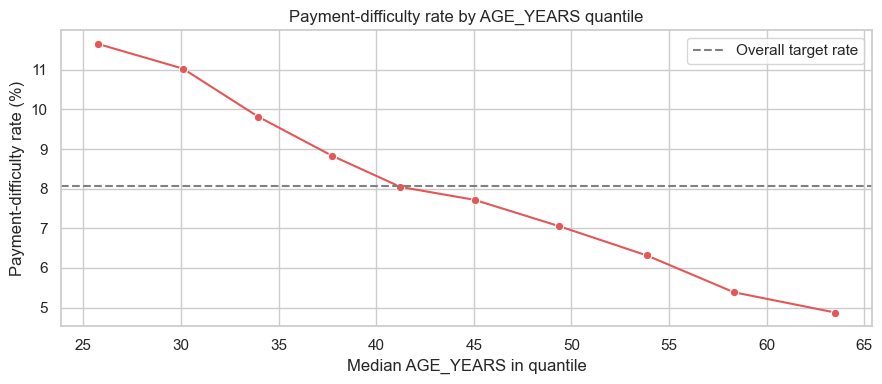

,bin,feature_mean,feature_median,application_count,target_rate,target_rate_pct
0,"(20.503, 28.137]",25.452,25.739,24603,0.117,11.653
1,"(28.137, 31.992]",30.092,30.105,24602,0.110,11.028
2,"(31.992, 35.962]",33.965,33.952,24600,0.098,9.817
3,"(35.962, 39.452]",37.732,37.730,24613,0.088,8.833
4,"(39.452, 43.105]",41.257,41.243,24588,0.080,8.045
5,"(43.105, 47.132]",45.050,45.036,24604,0.077,7.718
6,"(47.132, 51.682]",49.378,49.366,24605,0.071,7.055
7,"(51.682, 56.021]",53.857,53.864,24591,0.063,6.315
8,"(56.021, 60.709]",58.329,58.322,24613,0.054,5.387
9,"(60.709, 69.073]",63.760,63.510,24589,0.049,4.876


In [43]:
age_target_table = plot_target_rate_by_quantile(
    numerical_eda_df,
    "AGE_YEARS",
)

age_target_table

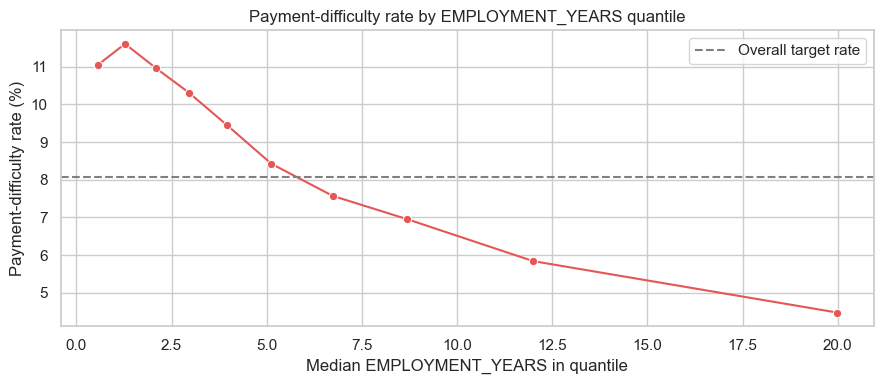

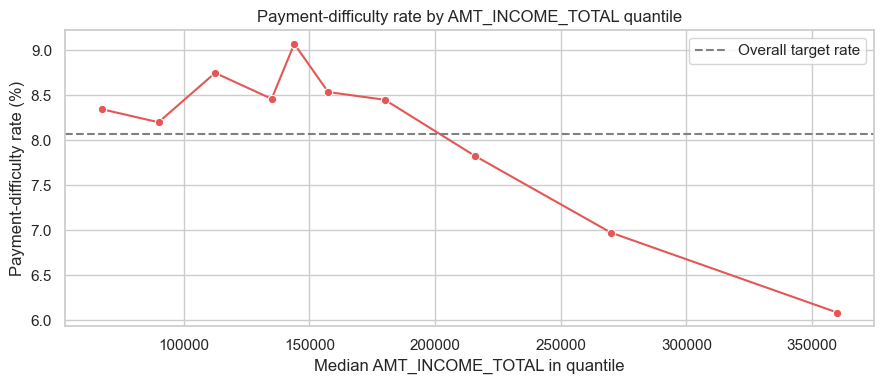

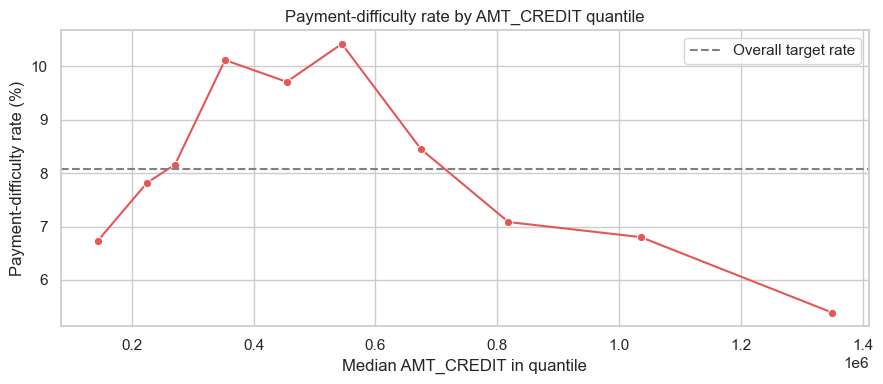

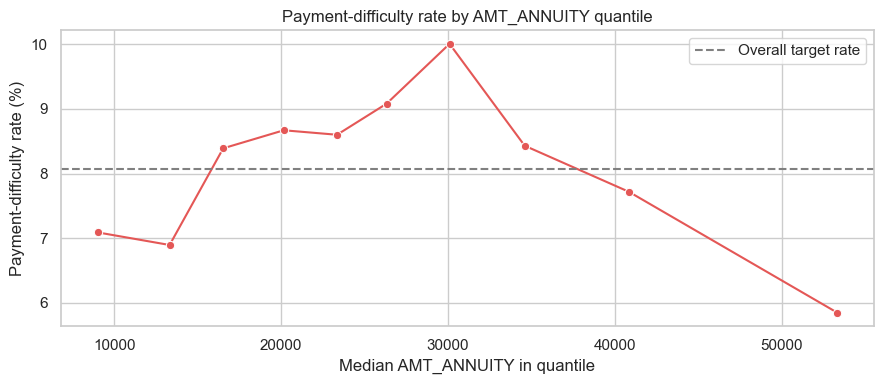

In [44]:
employment_target_table = plot_target_rate_by_quantile(
    numerical_eda_df,
    "EMPLOYMENT_YEARS",
)

income_target_table = plot_target_rate_by_quantile(
    numerical_eda_df,
    "AMT_INCOME_TOTAL",
)

credit_target_table = plot_target_rate_by_quantile(
    numerical_eda_df,
    "AMT_CREDIT",
)

annuity_target_table = plot_target_rate_by_quantile(
    numerical_eda_df,
    "AMT_ANNUITY",
)

In [45]:
employment_anomaly_summary = (
    numerical_eda_df
    .groupby(
        "DAYS_EMPLOYED_ANOMALOUS"
    )
    .agg(
        application_count=("TARGET", "size"),
        target_rate=("TARGET", "mean"),
        median_age=("AGE_YEARS", "median"),
        median_income=(
            "AMT_INCOME_TOTAL",
            "median",
        ),
    )
)

employment_anomaly_summary["percentage"] = (
    employment_anomaly_summary[
        "application_count"
    ]
    / len(numerical_eda_df)
    * 100
)

employment_anomaly_summary["target_rate_pct"] = (
    employment_anomaly_summary[
        "target_rate"
    ]
    * 100
)

employment_anomaly_summary

,application_count,target_rate,median_age,median_income,percentage,target_rate_pct
DAYS_EMPLOYED_ANOMALOUS,,,,,,
0,201865,0.087,39.893,"157,500.000",82.056,8.664
1,44143,0.054,60.359,"117,000.000",17.944,5.369


In [53]:
pd.crosstab(
    numerical_eda_df["NAME_INCOME_TYPE"],
    numerical_eda_df["DAYS_EMPLOYED_ANOMALOUS"],
    normalize="columns",
).mul(100).round(2)

DAYS_EMPLOYED_ANOMALOUS,0,1
NAME_INCOME_TYPE,,
Businessman,0.000,0.000
Commercial associate,28.370,0.000
Maternity leave,0.000,0.000
Pensioner,0.000,99.960
State servant,8.680,0.000
Student,0.010,0.000
Unemployed,0.000,0.040
Working,62.930,0.000


In [47]:
ext_source_features = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
]

numerical_eda_df[
    ext_source_features
].describe(
    percentiles=[
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99,
    ]
).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
EXT_SOURCE_1,"107,413.000",0.502,0.211,0.015,0.084,0.157,0.333,0.505,0.675,0.832,0.890,0.952
EXT_SOURCE_2,"245,477.000",0.514,0.191,0.000,0.029,0.132,0.392,0.566,0.664,0.748,0.783,0.855
EXT_SOURCE_3,"197,203.000",0.511,0.195,0.001,0.065,0.155,0.371,0.535,0.669,0.786,0.834,0.896


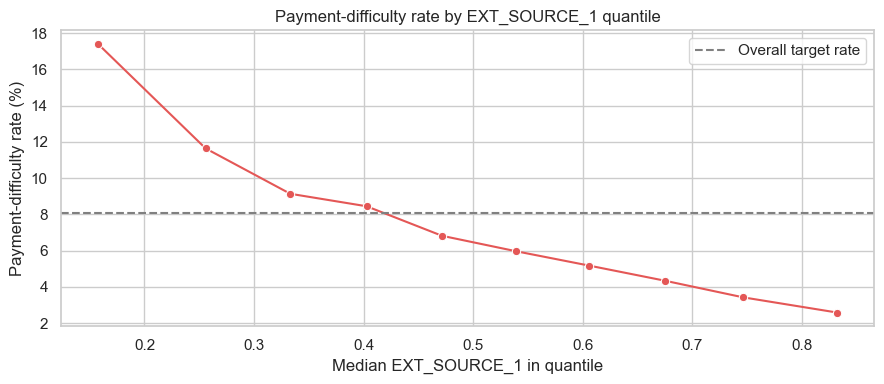

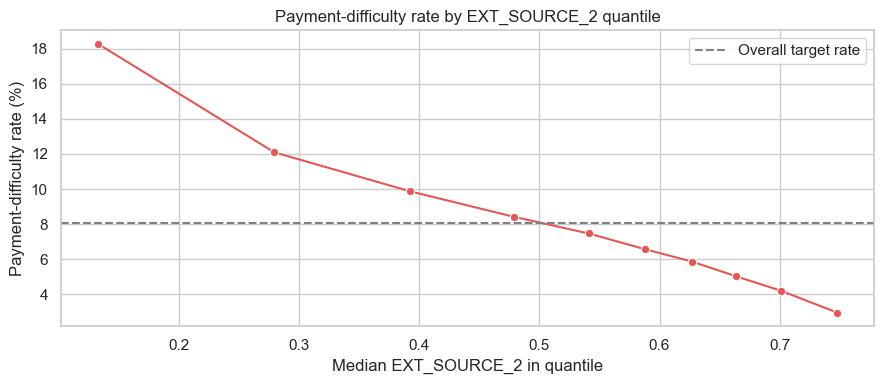

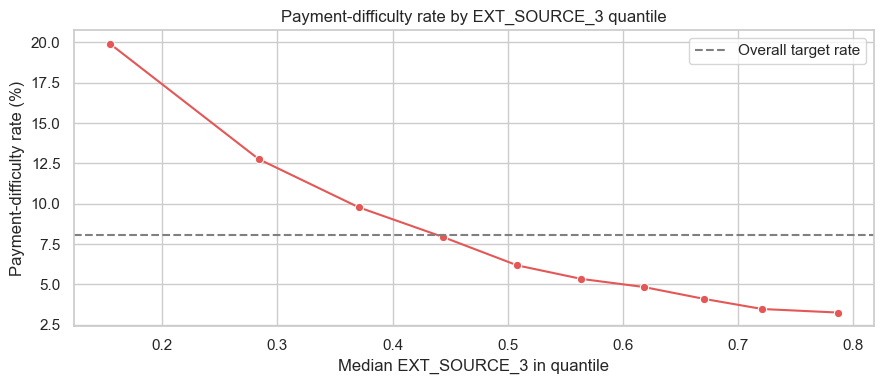

In [48]:
ext_source_tables = {}

for feature in ext_source_features:
    ext_source_tables[feature] = (
        plot_target_rate_by_quantile(
            numerical_eda_df,
            feature,
        )
    )

In [50]:
numerical_eda_df["EXT_SOURCE_AVAILABLE_COUNT"] = (
    numerical_eda_df[ext_source_features]
    .notna()
    .sum(axis=1)
)

ext_availability_summary = (
    numerical_eda_df
    .groupby(
        "EXT_SOURCE_AVAILABLE_COUNT"
    )
    .agg(
        application_count=("TARGET", "size"),
        target_rate=("TARGET", "mean"),
    )
)

ext_availability_summary["percentage"] = (
    ext_availability_summary[
        "application_count"
    ]
    / len(numerical_eda_df)
    * 100
)

ext_availability_summary["target_rate_pct"] = (
    ext_availability_summary[
        "target_rate"
    ]
    * 100
)

ext_availability_summary

,application_count,target_rate,percentage,target_rate_pct
EXT_SOURCE_AVAILABLE_COUNT,,,,
0,139,0.086,0.057,8.633
1,29276,0.099,11.900,9.943
2,128962,0.082,52.422,8.162
3,87631,0.073,35.621,7.316


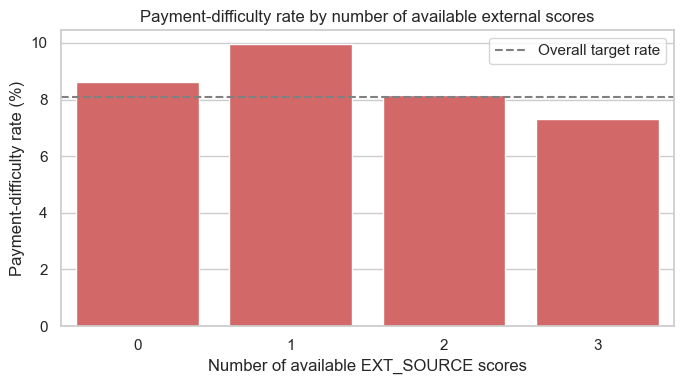

In [51]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(
    data=ext_availability_summary.reset_index(),
    x="EXT_SOURCE_AVAILABLE_COUNT",
    y="target_rate_pct",
    color="#E45756",
    ax=ax,
)

ax.axhline(
    numerical_eda_df["TARGET"].mean() * 100,
    linestyle="--",
    color="gray",
    label="Overall target rate",
)

ax.set_title(
    "Payment-difficulty rate by number of available external scores"
)
ax.set_xlabel("Number of available EXT_SOURCE scores")
ax.set_ylabel("Payment-difficulty rate (%)")
ax.legend()

plt.tight_layout()
plt.show()

## Numerical-feature findings

- Applicant age exhibits a clear decreasing association with payment difficulty.
  The target rate falls almost monotonically from 11.65% in the youngest age
  decile to 4.88% in the oldest decile. This is an association and should not
  be interpreted causally.

- Employment duration also shows a broadly decreasing relationship with payment
  difficulty. Applicants with shorter observed employment histories have higher
  target rates than those with longer histories.

- `AMT_INCOME_TOTAL` is extremely right-skewed. Its 99th percentile is 472,500,
  whereas its maximum is 117,000,000. Despite this extreme distribution, its
  standardized mean difference between target groups is approximately zero
  (`SMD = -0.004`). Raw income alone therefore provides little separation
  between the two groups, although relative-income features may be more useful.

- `DAYS_EMPLOYED = 365243` affects 17.94% of applications. Applicants with this
  sentinel value are substantially older (median age 60.36 versus 39.89) and
  have a lower observed target rate (5.37% versus 8.66%). The sentinel is
  therefore structured information and should be represented by an indicator
  rather than treated as an ordinary employment duration.

- `EXT_SOURCE_1`, `EXT_SOURCE_2` and `EXT_SOURCE_3` provide the strongest
  univariate separation among the numerical features examined. Their absolute
  standardized mean differences range from 0.559 to 0.657, and all three show
  a strong monotonic decrease in target rate as the score increases.

- External-score availability also contains information. Applications with one
  available score have a target rate of 9.94%, compared with 7.32% for
  applications with all three scores. The group with no available scores
  contains only 139 observations and should not be interpreted independently.

- Numerical relationships are not assumed to be linear. Quantile-based analysis
  indicates that nonlinear models, transformations and relative financial
  features should be evaluated during modeling.

- All transformations introduced during EDA must be reproduced from the original
  variables inside the modeling pipeline.

## 4. Financial ratios and interactions

In [55]:
ratio_eda_df = numerical_eda_df.copy()
def safe_divide(
    numerator: pd.Series,
    denominator: pd.Series,
) -> pd.Series:
    result = numerator.div(
        denominator.where(denominator > 0)
    )

    return result.replace(
        [np.inf, -np.inf],
        np.nan,
    )

In [56]:
denominator_checks = pd.DataFrame(
    {
        "missing_count": ratio_eda_df[
            [
                "AMT_INCOME_TOTAL",
                "AMT_CREDIT",
                "AMT_ANNUITY",
                "AMT_GOODS_PRICE",
                "CNT_FAM_MEMBERS",
                "AGE_YEARS",
            ]
        ].isna().sum(),
        "non_positive_count": (
            ratio_eda_df[
                [
                    "AMT_INCOME_TOTAL",
                    "AMT_CREDIT",
                    "AMT_ANNUITY",
                    "AMT_GOODS_PRICE",
                    "CNT_FAM_MEMBERS",
                    "AGE_YEARS",
                ]
            ]
            .le(0)
            .sum()
        ),
    }
)

denominator_checks

,missing_count,non_positive_count
AMT_INCOME_TOTAL,0,0
AMT_CREDIT,0,0
AMT_ANNUITY,10,0
AMT_GOODS_PRICE,221,0
CNT_FAM_MEMBERS,2,0
AGE_YEARS,0,0


In [57]:
ratio_eda_df["CREDIT_INCOME_RATIO"] = safe_divide(
    ratio_eda_df["AMT_CREDIT"],
    ratio_eda_df["AMT_INCOME_TOTAL"],
)

ratio_eda_df["ANNUITY_INCOME_RATIO"] = safe_divide(
    ratio_eda_df["AMT_ANNUITY"],
    ratio_eda_df["AMT_INCOME_TOTAL"],
)

ratio_eda_df["CREDIT_GOODS_RATIO"] = safe_divide(
    ratio_eda_df["AMT_CREDIT"],
    ratio_eda_df["AMT_GOODS_PRICE"],
)

ratio_eda_df["ANNUITY_CREDIT_RATIO"] = safe_divide(
    ratio_eda_df["AMT_ANNUITY"],
    ratio_eda_df["AMT_CREDIT"],
)

ratio_eda_df["CREDIT_TERM_PROXY"] = safe_divide(
    ratio_eda_df["AMT_CREDIT"],
    ratio_eda_df["AMT_ANNUITY"],
)

ratio_eda_df["INCOME_PER_PERSON"] = safe_divide(
    ratio_eda_df["AMT_INCOME_TOTAL"],
    ratio_eda_df["CNT_FAM_MEMBERS"],
)

ratio_eda_df["EMPLOYED_AGE_RATIO"] = safe_divide(
    ratio_eda_df["EMPLOYMENT_YEARS"],
    ratio_eda_df["AGE_YEARS"],
)

In [58]:
ratio_features = [
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_GOODS_RATIO",
    "ANNUITY_CREDIT_RATIO",
    "CREDIT_TERM_PROXY",
    "INCOME_PER_PERSON",
    "EMPLOYED_AGE_RATIO",
]

ratio_summary = numerical_feature_summary(
    ratio_eda_df,
    ratio_features,
)

ratio_summary

,missing_pct,n_unique,mean,median,std,min,p01,p99,max,skewness
feature,,,,,,,,,,
CREDIT_INCOME_RATIO,0.000,42625,3.959,3.269,2.688,0.005,0.596,13.036,49.227,1.758
ANNUITY_INCOME_RATIO,0.004,77864,0.181,0.163,0.095,0.000,0.039,0.484,1.571,1.498
CREDIT_GOODS_RATIO,0.090,2878,1.123,1.119,0.124,0.150,1.000,1.475,6.000,1.484
ANNUITY_CREDIT_RATIO,0.004,35571,0.054,0.050,0.022,0.022,0.026,0.114,0.124,1.119
CREDIT_TERM_PROXY,0.004,35571,21.624,20.000,7.821,8.037,8.734,37.795,45.305,0.304
INCOME_PER_PERSON,0.001,2625,"93,113.103","75,000.000","106,834.976","3,375.000","18,000.000","337,500.000","39,000,000.000",198.792
EMPLOYED_AGE_RATIO,17.944,200541,0.157,0.119,0.134,-0.000,0.008,0.590,0.729,1.346


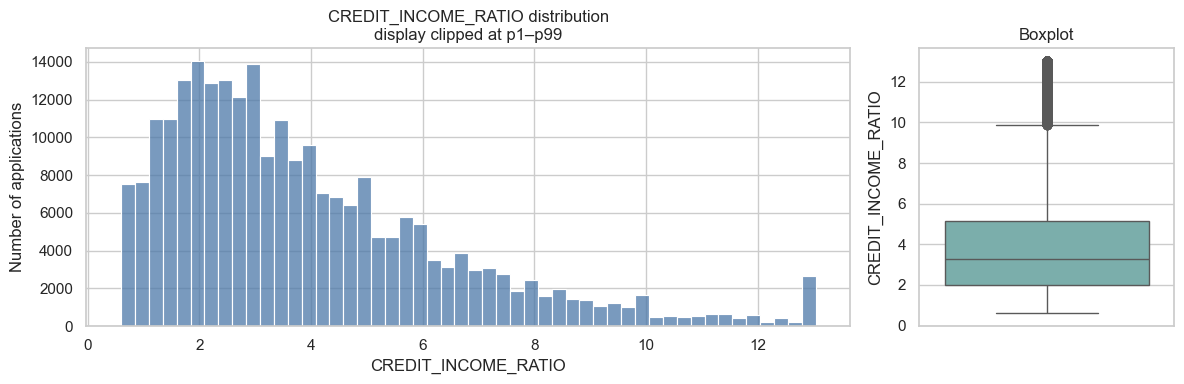

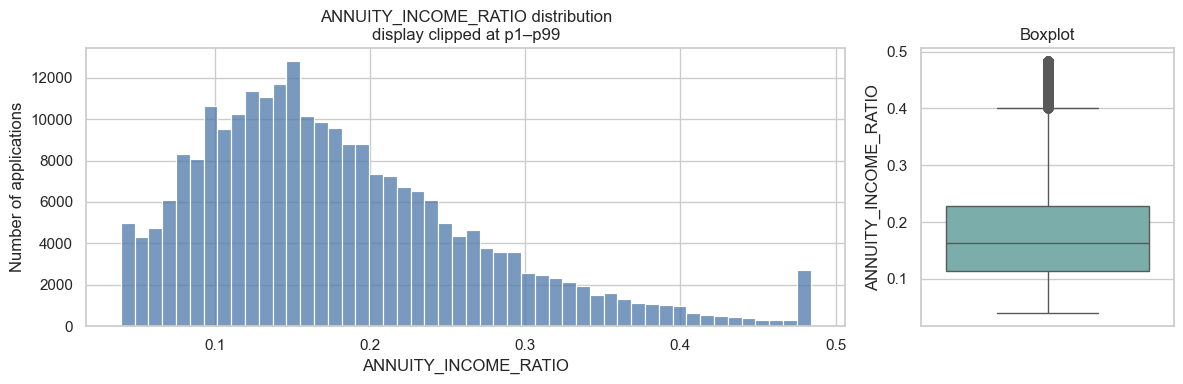

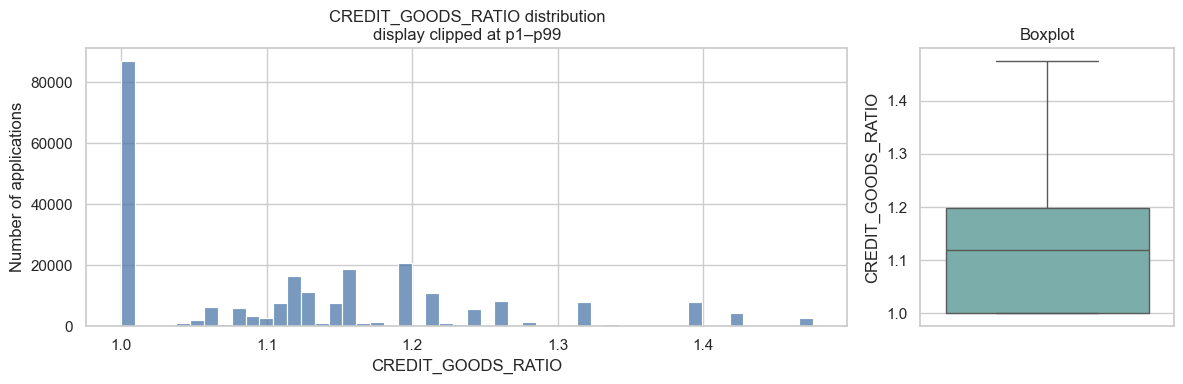

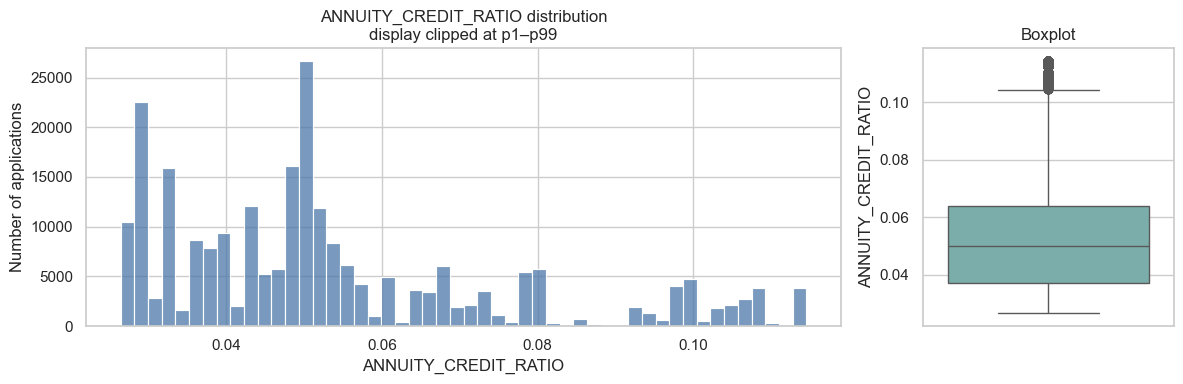

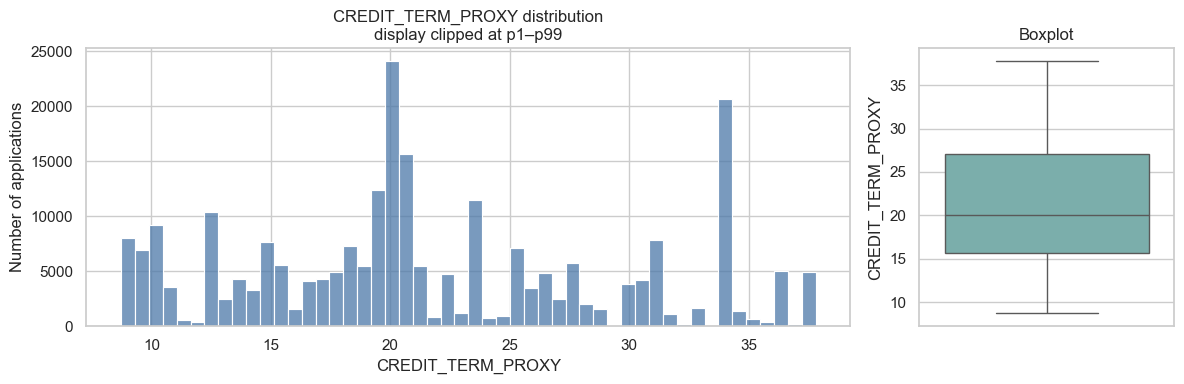

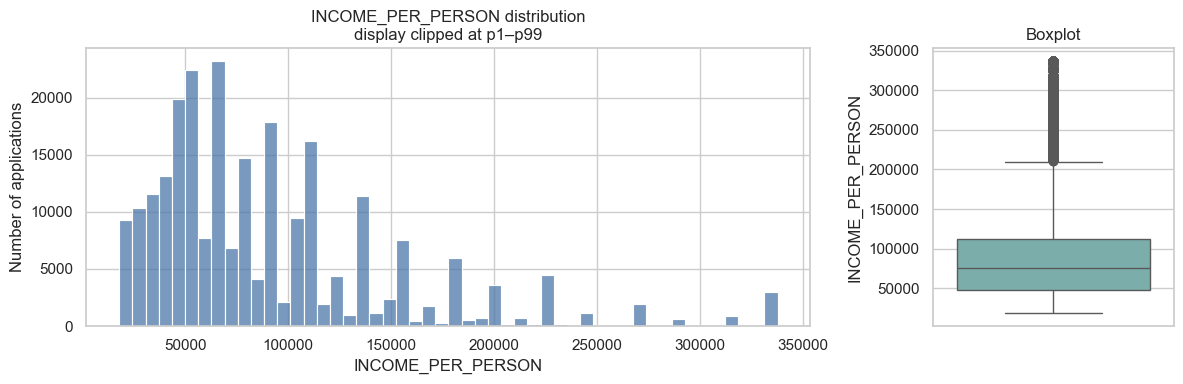

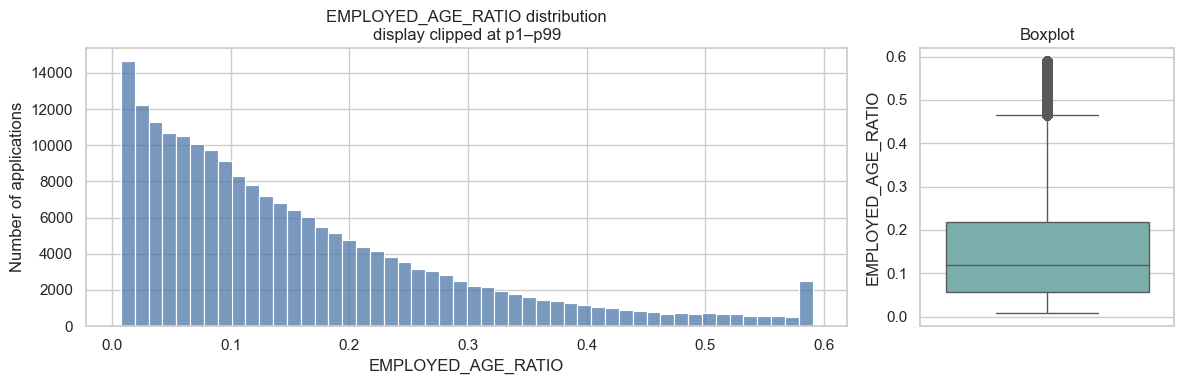

In [59]:
for feature in ratio_features:
    plot_clipped_distribution(
        ratio_eda_df,
        feature,
    )

In [60]:
ratio_logic_checks = pd.Series(
    {
        "credit_goods_ratio_below_1": (
            ratio_eda_df["CREDIT_GOODS_RATIO"] < 1
        ).sum(),
        "credit_goods_ratio_equal_1": np.isclose(
            ratio_eda_df["CREDIT_GOODS_RATIO"],
            1,
        ).sum(),
        "credit_goods_ratio_above_1": (
            ratio_eda_df["CREDIT_GOODS_RATIO"] > 1
        ).sum(),
        "employed_age_ratio_above_1": (
            ratio_eda_df["EMPLOYED_AGE_RATIO"] > 1
        ).sum(),
    }
)

ratio_logic_checks

credit_goods_ratio_below_1       201
credit_goods_ratio_equal_1     86601
credit_goods_ratio_above_1    158985
employed_age_ratio_above_1         0
dtype: int64

In [61]:
ratio_by_target = summarize_by_target(
    ratio_eda_df,
    ratio_features,
)

ratio_by_target

,feature,target,count_observed,missing_pct,mean,median,p25,p75
0,CREDIT_INCOME_RATIO,0,226148,0.000,3.965,3.270,2.000,5.200
1,CREDIT_INCOME_RATIO,1,19860,0.000,3.892,3.250,2.130,4.983
2,ANNUITY_INCOME_RATIO,0,226138,0.004,0.180,0.162,0.114,0.228
3,ANNUITY_INCOME_RATIO,1,19860,0.000,0.186,0.170,0.120,0.234
4,CREDIT_GOODS_RATIO,0,225944,0.090,1.120,1.119,1.000,1.198
5,CREDIT_GOODS_RATIO,1,19843,0.086,1.152,1.145,1.000,1.211
6,ANNUITY_CREDIT_RATIO,0,226138,0.004,0.054,0.050,0.036,0.063
7,ANNUITY_CREDIT_RATIO,1,19860,0.000,0.055,0.050,0.040,0.067
8,CREDIT_TERM_PROXY,0,226138,0.004,21.701,20.000,15.910,27.567
9,CREDIT_TERM_PROXY,1,19860,0.000,20.748,20.000,14.964,25.215


In [62]:
ratio_median_by_target = (
    ratio_by_target
    .pivot(
        index="feature",
        columns="target",
        values="median",
    )
    .rename(
        columns={
            0: "median_target_0",
            1: "median_target_1",
        }
    )
)

ratio_median_by_target[
    "relative_median_difference_pct"
] = (
    (
        ratio_median_by_target["median_target_1"]
        - ratio_median_by_target["median_target_0"]
    )
    / ratio_median_by_target["median_target_0"].abs()
    * 100
)

ratio_median_by_target

target,median_target_0,median_target_1,relative_median_difference_pct
feature,,,
ANNUITY_CREDIT_RATIO,0.050,0.050,0.000
ANNUITY_INCOME_RATIO,0.162,0.170,4.461
CREDIT_GOODS_RATIO,1.119,1.145,2.360
CREDIT_INCOME_RATIO,3.270,3.250,-0.619
CREDIT_TERM_PROXY,20.000,20.000,0.000
EMPLOYED_AGE_RATIO,0.122,0.094,-22.615
INCOME_PER_PERSON,"75,000.000","67,500.000",-10.000


In [63]:
ratio_effect_size = pd.DataFrame(
    {
        "feature": ratio_features,
        "standardized_mean_difference": [
            standardized_mean_difference(
                ratio_eda_df,
                feature,
            )
            for feature in ratio_features
        ],
    }
)

ratio_effect_size["absolute_smd"] = (
    ratio_effect_size[
        "standardized_mean_difference"
    ].abs()
)

ratio_effect_size = ratio_effect_size.sort_values(
    "absolute_smd",
    ascending=False,
)

ratio_effect_size

,feature,standardized_mean_difference,absolute_smd
6,EMPLOYED_AGE_RATIO,-0.259,0.259
2,CREDIT_GOODS_RATIO,0.242,0.242
4,CREDIT_TERM_PROXY,-0.127,0.127
1,ANNUITY_INCOME_RATIO,0.057,0.057
3,ANNUITY_CREDIT_RATIO,0.053,0.053
0,CREDIT_INCOME_RATIO,-0.028,0.028
5,INCOME_PER_PERSON,-0.010,0.010


In [64]:
raw_and_ratio_effect_size = pd.concat(
    [
        effect_size_summary.assign(
            feature_type="original",
        ),
        ratio_effect_size.assign(
            feature_type="engineered",
        ),
    ],
    ignore_index=True,
)

raw_and_ratio_effect_size.sort_values(
    "absolute_smd",
    ascending=False,
)

,feature,standardized_mean_difference,absolute_smd,feature_type
8,EXT_SOURCE_3,-0.657,0.657,original
6,EXT_SOURCE_1,-0.603,0.603,original
7,EXT_SOURCE_2,-0.559,0.559,original
0,AGE_YEARS,-0.298,0.298,original
1,EMPLOYMENT_YEARS,-0.294,0.294,original
9,EMPLOYED_AGE_RATIO,-0.259,0.259,engineered
10,CREDIT_GOODS_RATIO,0.242,0.242,engineered
5,AMT_GOODS_PRICE,-0.157,0.157,original
11,CREDIT_TERM_PROXY,-0.127,0.127,engineered
3,AMT_CREDIT,-0.120,0.120,original


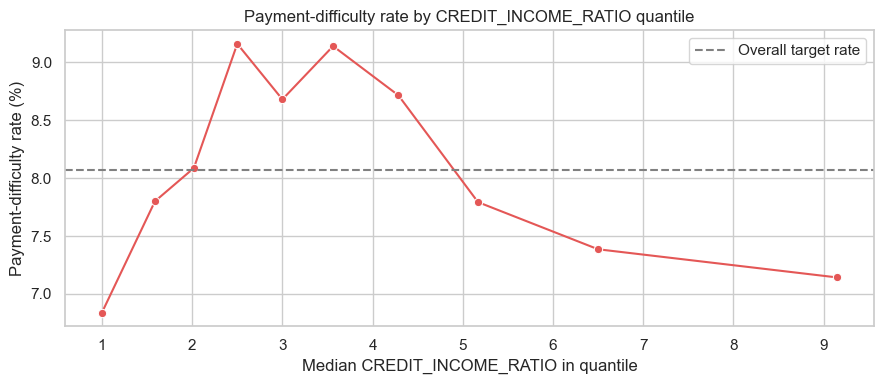

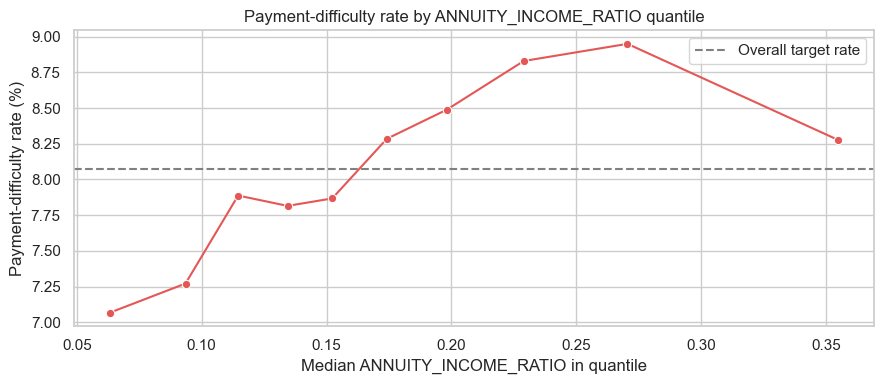

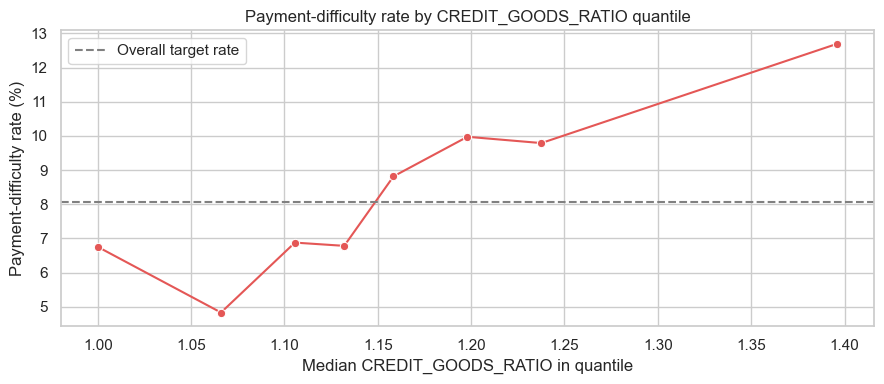

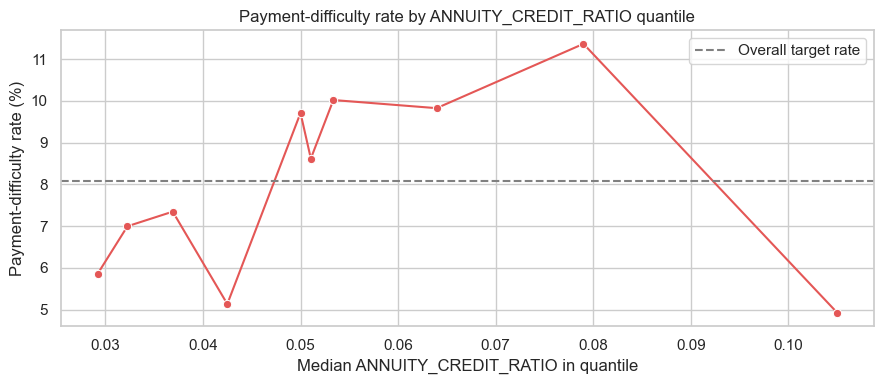

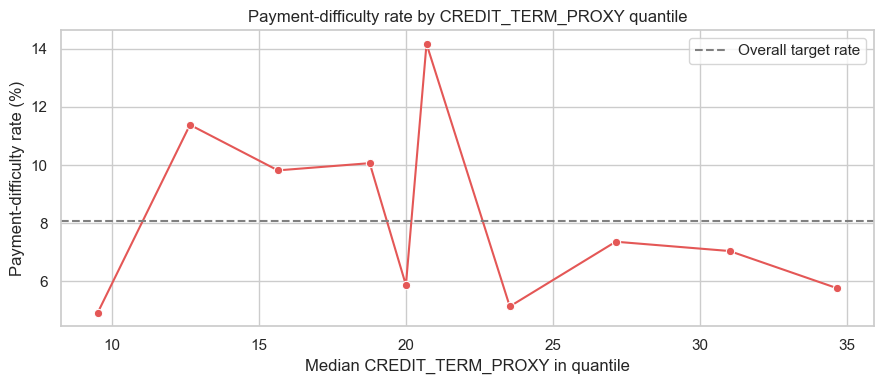

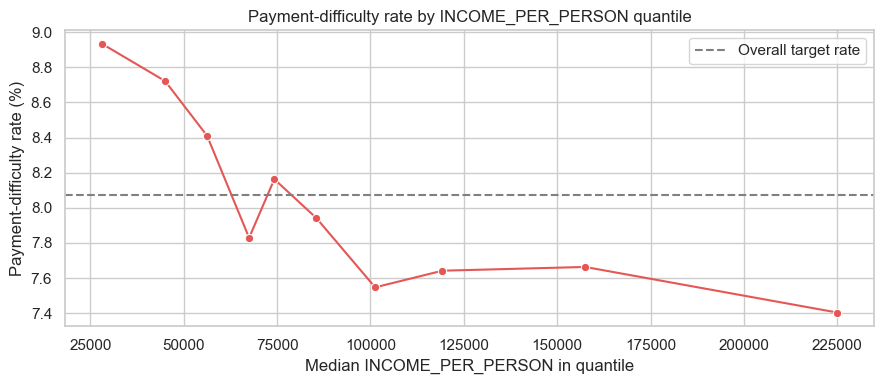

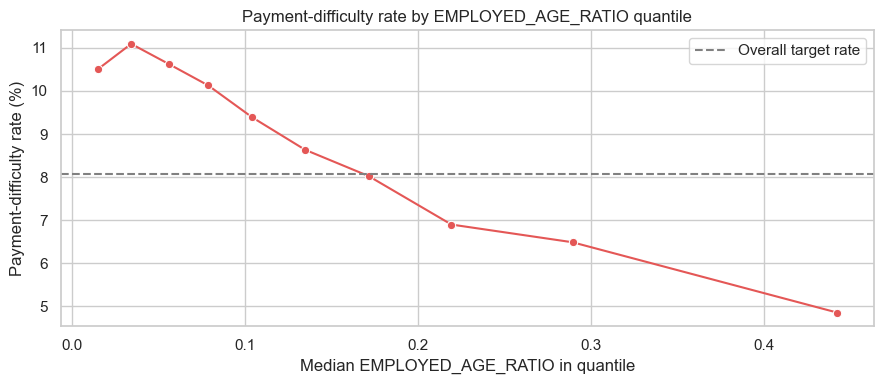

In [65]:
ratio_target_tables = {}

for feature in ratio_features:
    ratio_target_tables[feature] = (
        plot_target_rate_by_quantile(
            ratio_eda_df,
            feature,
        )
    )

In [66]:
ratio_target_tables[
    "ANNUITY_INCOME_RATIO"
]

,bin,feature_mean,feature_median,application_count,target_rate,target_rate_pct
0,"(-0.000776, 0.08]",0.061,0.063,25311,0.071,7.068
1,"(0.08, 0.104]",0.093,0.094,23889,0.073,7.271
2,"(0.104, 0.125]",0.114,0.115,24609,0.079,7.887
3,"(0.125, 0.144]",0.134,0.134,24607,0.078,7.815
4,"(0.144, 0.163]",0.153,0.152,24584,0.079,7.867
5,"(0.163, 0.186]",0.174,0.174,24624,0.083,8.285
6,"(0.186, 0.212]",0.199,0.198,24574,0.085,8.489
7,"(0.212, 0.247]",0.229,0.229,24600,0.088,8.829
8,"(0.247, 0.302]",0.272,0.271,24605,0.089,8.949
9,"(0.302, 1.571]",0.381,0.355,24595,0.083,8.278


In [67]:
ratio_target_tables[
    "CREDIT_INCOME_RATIO"
]

,bin,feature_mean,feature_median,application_count,target_rate,target_rate_pct
0,"(0.00381, 1.332]",0.965,1.000,24768,0.068,6.839
1,"(1.332, 1.818]",1.577,1.587,24463,0.078,7.800
2,"(1.818, 2.264]",2.049,2.019,24608,0.081,8.087
3,"(2.264, 2.765]",2.516,2.500,24589,0.092,9.159
4,"(2.765, 3.269]",2.995,3.000,24576,0.087,8.679
5,"(3.269, 3.912]",3.568,3.562,24609,0.091,9.139
6,"(3.912, 4.732]",4.288,4.286,24592,0.087,8.714
7,"(4.732, 5.777]",5.214,5.169,24601,0.078,7.792
8,"(5.777, 7.488]",6.526,6.500,24616,0.074,7.385
9,"(7.488, 49.227]",9.903,9.151,24586,0.071,7.142


In [68]:
correlation_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    *ratio_features,
]

spearman_correlation = ratio_eda_df[
    correlation_features
].corr(method="spearman")

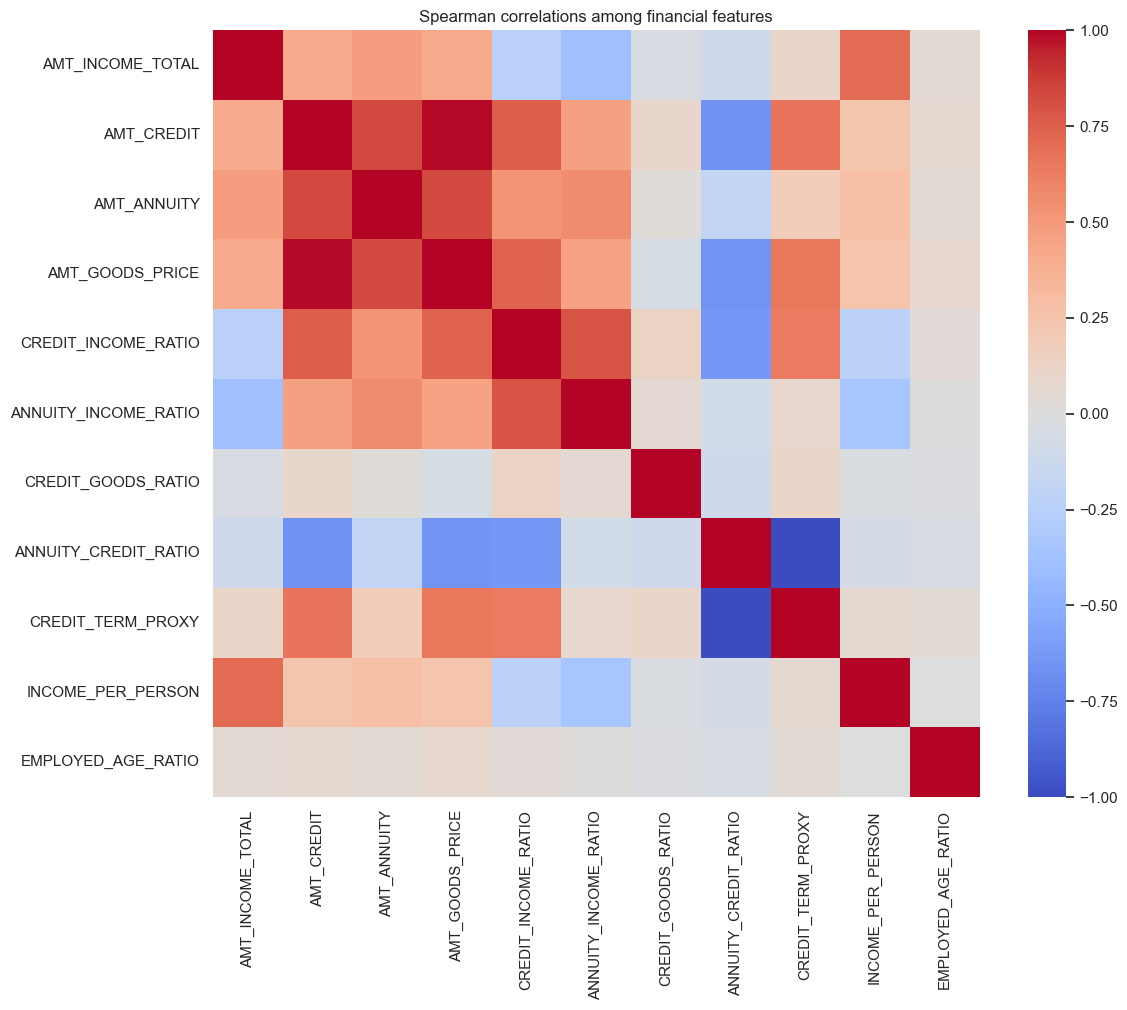

In [69]:
fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    spearman_correlation,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=ax,
)

ax.set_title(
    "Spearman correlations among financial features"
)

plt.tight_layout()
plt.show()

In [70]:
upper_triangle = (
    spearman_correlation
    .where(
        np.triu(
            np.ones(
                spearman_correlation.shape,
                dtype=bool,
            ),
            k=1,
        )
    )
    .stack()
    .rename("spearman_correlation")
    .reset_index()
    .rename(
        columns={
            "level_0": "feature_1",
            "level_1": "feature_2",
        }
    )
)

strong_correlation_pairs = (
    upper_triangle
    .assign(
        absolute_correlation=lambda df: (
            df["spearman_correlation"].abs()
        )
    )
    .query("absolute_correlation >= 0.80")
    .sort_values(
        "absolute_correlation",
        ascending=False,
    )
)

strong_correlation_pairs

,feature_1,feature_2,spearman_correlation,absolute_correlation
49,ANNUITY_CREDIT_RATIO,CREDIT_TERM_PROXY,-1.000,1.000
11,AMT_CREDIT,AMT_GOODS_PRICE,0.985,0.985
10,AMT_CREDIT,AMT_ANNUITY,0.831,0.831
19,AMT_ANNUITY,AMT_GOODS_PRICE,0.828,0.828


In [71]:
interaction_data = ratio_eda_df[
    [
        "AGE_YEARS",
        "ANNUITY_INCOME_RATIO",
        "TARGET",
    ]
].dropna().copy()

interaction_data["AGE_QUINTILE"] = pd.qcut(
    interaction_data["AGE_YEARS"],
    q=5,
    duplicates="drop",
)

interaction_data["ANNUITY_INCOME_QUINTILE"] = pd.qcut(
    interaction_data["ANNUITY_INCOME_RATIO"],
    q=5,
    duplicates="drop",
)

age_burden_interaction = (
    interaction_data
    .pivot_table(
        index="AGE_QUINTILE",
        columns="ANNUITY_INCOME_QUINTILE",
        values="TARGET",
        aggfunc="mean",
        observed=True,
    )
    .mul(100)
)

age_burden_interaction

ANNUITY_INCOME_QUINTILE,"(-0.000776, 0.104]","(0.104, 0.144]","(0.144, 0.186]","(0.186, 0.247]","(0.247, 1.571]"
AGE_QUINTILE,,,,,
"(20.503, 31.992]",8.859,11.065,11.377,12.648,13.633
"(31.992, 39.452]",7.759,8.870,9.520,10.504,10.140
"(39.452, 47.132]",7.098,7.457,8.101,8.237,8.535
"(47.132, 56.022]",6.331,6.752,6.508,7.016,6.777
"(56.022, 69.073]",5.013,4.891,4.949,5.214,5.496


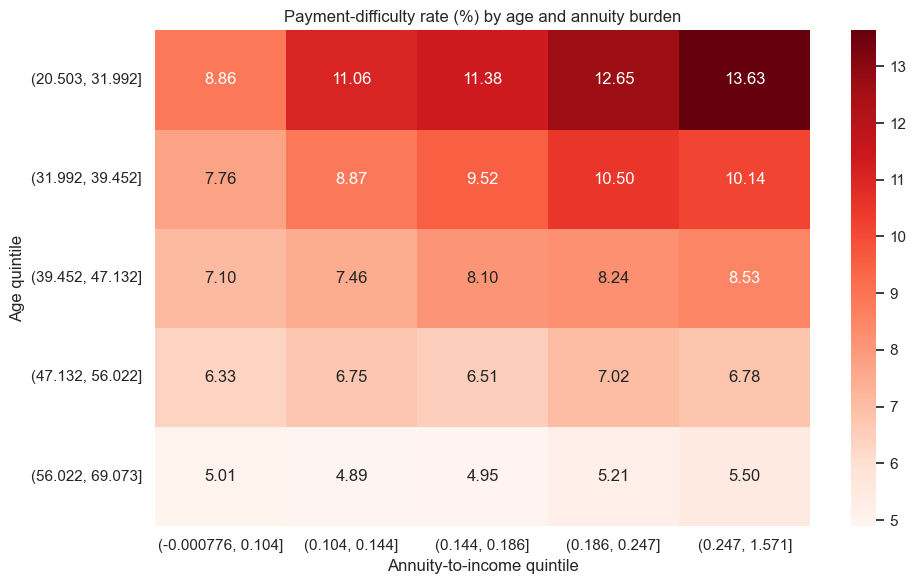

In [72]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    age_burden_interaction,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    ax=ax,
)

ax.set_title(
    "Payment-difficulty rate (%) by age and annuity burden"
)
ax.set_xlabel("Annuity-to-income quintile")
ax.set_ylabel("Age quintile")

plt.tight_layout()
plt.show()

## Financial-ratio and interaction findings

- `ANNUITY_INCOME_RATIO` exhibits a broadly increasing but non-monotonic
  association with payment difficulty. The target rate rises from 7.07% in the
  lowest burden decile to a peak of 8.95% in the ninth decile, before falling to
  8.28% in the highest decile. Its univariate standardized mean difference is
  nevertheless small (`SMD = 0.057`).

- `CREDIT_INCOME_RATIO` does not provide clearer linear separation than raw
  credit: its absolute SMD is 0.028, compared with 0.120 for `AMT_CREDIT`.
  However, the decile analysis reveals a non-monotonic, hump-shaped pattern:
  the target rate increases from 6.84% in the lowest decile to about 9.16% in
  the fourth decile, then declines to 7.14% in the highest decile.

- `CREDIT_GOODS_RATIO` is concentrated around 1.12. Among applications with an
  observed goods price, 64.68% have credit greater than the recorded goods
  price. These observations are not automatically treated as data errors.

- `EMPLOYED_AGE_RATIO` has the largest absolute SMD among the engineered
  features (`|SMD| = 0.259`), followed by `CREDIT_GOODS_RATIO`
  (`|SMD| = 0.242`). These are meaningful univariate associations, but they do
  not establish incremental value beyond their source variables.

- `ANNUITY_CREDIT_RATIO` and `CREDIT_TERM_PROXY` are exact monotonic inverses
  (`Spearman = -1.000`). Raw credit is also strongly correlated with goods
  price (`0.985`) and annuity (`0.831`). Redundant inverse features should not
  both be included in a linear model without a specific justification.

- The age–annuity-burden table shows a clear age-dependent pattern. Among the
  youngest quintile, the target rate rises from 8.86% in the lowest burden
  quintile to 13.63% in the highest; among the oldest quintile, it changes only
  from 5.01% to 5.50%. This descriptive interaction must be tested through
  cross-validation before being retained.

- Ratio construction does not use the target, but the same definitions and
  denominator handling must be implemented inside the feature-engineering
  pipeline.

## 5. Categorical features and payment difficulty

This section examines category frequencies, target rates, missing and special
labels, rare levels, and univariate association strength.

Target-rate comparisons are restricted to the development set. Small groups
are flagged because their observed rates are unstable. No target-derived
encoding is created during EDA.

In [74]:
categorical_features = (
    eda_df
    .select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)


def categorical_feature_profile(
    df: pd.DataFrame,
    features: list[str],
    missing_label: str = "__MISSING__",
) -> pd.DataFrame:
    records = []

    for feature in features:
        values = (
            df[feature]
            .astype("string")
            .fillna(missing_label)
        )
        counts = values.value_counts(dropna=False)

        records.append(
            {
                "feature": feature,
                "dtype": str(df[feature].dtype),
                "missing_count": df[feature].isna().sum(),
                "missing_pct": df[feature].isna().mean() * 100,
                "n_categories_including_missing": values.nunique(),
                "most_frequent_category": counts.index[0],
                "most_frequent_count": counts.iloc[0],
                "most_frequent_share_pct": (
                    counts.iloc[0] / len(df) * 100
                ),
            }
        )

    return (
        pd.DataFrame(records)
        .sort_values(
            [
                "n_categories_including_missing",
                "missing_pct",
            ],
            ascending=[False, False],
        )
        .reset_index(drop=True)
    )


categorical_profile = categorical_feature_profile(
    eda_df,
    categorical_features,
)

categorical_profile

,feature,dtype,missing_count,missing_pct,n_categories_including_missing,most_frequent_category,most_frequent_count,most_frequent_share_pct
0,ORGANIZATION_TYPE,object,0,0.000,58,Business Entity Type 3,54436,22.128
1,OCCUPATION_TYPE,object,76940,31.275,19,__MISSING__,76940,31.275
2,WALLSMATERIAL_MODE,object,124975,50.801,8,__MISSING__,124975,50.801
3,NAME_TYPE_SUITE,object,1029,0.418,8,Unaccompanied,198808,80.814
4,NAME_INCOME_TYPE,object,0,0.000,8,Working,127043,51.642
5,WEEKDAY_APPR_PROCESS_START,object,0,0.000,7,TUESDAY,43167,17.547
6,NAME_FAMILY_STATUS,object,0,0.000,6,Married,157153,63.881
7,NAME_HOUSING_TYPE,object,0,0.000,6,House / apartment,218383,88.771
8,FONDKAPREMONT_MODE,object,168215,68.378,5,__MISSING__,168215,68.378
9,NAME_EDUCATION_TYPE,object,0,0.000,5,Secondary / secondary special,174768,71.042


In [75]:
special_labels = {
    "XNA",
    "Unknown",
    "UNKNOWN",
    "Unspecified",
}

special_label_records = []

for feature in categorical_features:
    values = eda_df[feature].astype("string")

    for label in special_labels:
        label_count = values.eq(label).sum()

        if label_count > 0:
            special_label_records.append(
                {
                    "feature": feature,
                    "label": label,
                    "count": label_count,
                    "share_pct": (
                        label_count / len(eda_df) * 100
                    ),
                    "target_rate_pct": (
                        eda_df.loc[
                            values.eq(label),
                            "TARGET",
                        ].mean()
                        * 100
                    ),
                }
            )

special_label_summary = (
    pd.DataFrame(
        special_label_records,
        columns=[
            "feature",
            "label",
            "count",
            "share_pct",
            "target_rate_pct",
        ],
    )
    .sort_values(
        "count",
        ascending=False,
    )
    .reset_index(drop=True)
)

special_label_summary

,feature,label,count,share_pct,target_rate_pct
0,ORGANIZATION_TYPE,XNA,44143,17.944,5.369
1,CODE_GENDER,XNA,2,0.001,0.000
2,NAME_FAMILY_STATUS,Unknown,2,0.001,0.000


In [76]:
def categorical_target_table(
    df: pd.DataFrame,
    feature: str,
    target: str = "TARGET",
    missing_label: str = "__MISSING__",
    min_count: int = 500,
    min_target_count: int = 30,
) -> pd.DataFrame:
    analysis_data = df[
        [feature, target]
    ].copy()

    analysis_data["category"] = (
        analysis_data[feature]
        .astype("string")
        .fillna(missing_label)
    )

    result = (
        analysis_data
        .groupby(
            "category",
            observed=True,
        )
        .agg(
            application_count=(target, "size"),
            target_count=(target, "sum"),
            target_rate=(target, "mean"),
        )
        .reset_index()
    )

    result["application_share_pct"] = (
        result["application_count"]
        / len(df)
        * 100
    )
    result["target_rate_pct"] = (
        result["target_rate"] * 100
    )
    result["lift_vs_overall"] = (
        result["target_rate"]
        / df[target].mean()
    )

    z = 1.96
    n = result["application_count"]
    p = result["target_rate"]
    denominator = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denominator
    half_width = (
        z
        * np.sqrt(
            p * (1 - p) / n
            + z**2 / (4 * n**2)
        )
        / denominator
    )

    result["wilson_lower_pct"] = (
        (centre - half_width) * 100
    )
    result["wilson_upper_pct"] = (
        (centre + half_width) * 100
    )
    result["reliable_for_comparison"] = (
        (result["application_count"] >= min_count)
        & (result["target_count"] >= min_target_count)
    )

    return result.sort_values(
        [
            "target_rate",
            "application_count",
        ],
        ascending=[False, False],
    ).reset_index(drop=True)


In [77]:
key_categorical_features = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE",
]

key_categorical_features = [
    feature
    for feature in key_categorical_features
    if feature in categorical_features
]

categorical_target_tables = {
    feature: categorical_target_table(
        eda_df,
        feature,
    )
    for feature in key_categorical_features
}

for feature in [
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "OCCUPATION_TYPE",
]:
    if feature in categorical_target_tables:
        print(f"\n{feature}")
        display(categorical_target_tables[feature])


NAME_INCOME_TYPE


,category,application_count,target_count,target_rate,application_share_pct,target_rate_pct,lift_vs_overall,wilson_lower_pct,wilson_upper_pct,reliable_for_comparison
0,Unemployed,17,5,0.294,0.007,29.412,3.643,13.280,53.134,False
1,Working,127043,12118,0.095,51.642,9.539,1.182,9.378,9.701,True
2,Commercial associate,57273,4348,0.076,23.281,7.592,0.940,7.378,7.811,True
3,State servant,17518,1024,0.058,7.121,5.845,0.724,5.508,6.203,True
4,Pensioner,44134,2365,0.054,17.940,5.359,0.664,5.152,5.573,True
5,Student,11,0,0.000,0.004,0.000,0.000,0.000,25.884,False
6,Businessman,9,0,0.000,0.004,0.000,0.000,0.000,29.915,False
7,Maternity leave,3,0,0.000,0.001,0.000,0.000,0.000,56.151,False



NAME_EDUCATION_TYPE


,category,application_count,target_count,target_rate,application_share_pct,target_rate_pct,lift_vs_overall,wilson_lower_pct,wilson_upper_pct,reliable_for_comparison
0,Lower secondary,3025,335,0.111,1.230,11.074,1.372,10.005,12.242,True
1,Secondary / secondary special,174768,15582,0.089,71.042,8.916,1.104,8.783,9.050,True
2,Incomplete higher,8289,715,0.086,3.369,8.626,1.068,8.041,9.250,True
3,Higher education,59802,3226,0.054,24.309,5.394,0.668,5.216,5.578,True
4,Academic degree,124,2,0.016,0.050,1.613,0.200,0.443,5.690,False



OCCUPATION_TYPE


,category,application_count,target_count,target_rate,application_share_pct,target_rate_pct,lift_vs_overall,wilson_lower_pct,wilson_upper_pct,reliable_for_comparison
0,Low-skill Laborers,1696,307,0.181,0.689,18.101,2.242,16.342,20.005,True
1,Waiters/barmen staff,1046,120,0.115,0.425,11.472,1.421,9.680,13.546,True
2,Drivers,14944,1683,0.113,6.075,11.262,1.395,10.765,11.779,True
3,Security staff,5372,574,0.107,2.184,10.685,1.324,9.887,11.539,True
4,Laborers,44259,4657,0.105,17.991,10.522,1.303,10.240,10.811,True
5,Cooking staff,4767,501,0.105,1.938,10.510,1.302,9.671,11.412,True
6,Sales staff,25606,2458,0.096,10.409,9.599,1.189,9.245,9.966,True
7,Cleaning staff,3741,357,0.095,1.521,9.543,1.182,8.642,10.526,True
8,Realty agents,594,48,0.081,0.241,8.081,1.001,6.149,10.551,True
9,Secretaries,1047,75,0.072,0.426,7.163,0.887,5.753,8.887,True


In [78]:
def plot_categorical_target_rate(
    df: pd.DataFrame,
    feature: str,
    top_n: int = 20,
    min_count: int = 500,
    min_target_count: int = 30,
) -> pd.DataFrame:
    table = categorical_target_table(
        df=df,
        feature=feature,
        min_count=min_count,
        min_target_count=min_target_count,
    )

    plot_data = (
        table.loc[
            table["reliable_for_comparison"]
        ]
        .nlargest(
            top_n,
            "application_count",
        )
        .sort_values("target_rate_pct")
        .reset_index(drop=True)
    )

    if plot_data.empty:
        print(
            f"No category in {feature} meets "
            "the reliability thresholds."
        )
        return table

    fig_height = max(
        4,
        0.42 * len(plot_data),
    )
    fig, ax = plt.subplots(
        figsize=(10, fig_height)
    )

    sns.barplot(
        data=plot_data,
        x="target_rate_pct",
        y="category",
        color="#E45756",
        ax=ax,
    )

    x_error = np.vstack(
        [
            (
                plot_data["target_rate_pct"]
                - plot_data["wilson_lower_pct"]
            ).to_numpy(),
            (
                plot_data["wilson_upper_pct"]
                - plot_data["target_rate_pct"]
            ).to_numpy(),
        ]
    )

    ax.errorbar(
        x=plot_data["target_rate_pct"],
        y=np.arange(len(plot_data)),
        xerr=x_error,
        fmt="none",
        ecolor="black",
        elinewidth=1,
        capsize=2,
    )

    ax.axvline(
        df["TARGET"].mean() * 100,
        linestyle="--",
        color="gray",
        label="Overall target rate",
    )

    ax.set_title(
        f"Payment-difficulty rate by {feature}"
    )
    ax.set_xlabel(
        "Payment-difficulty rate (%)"
    )
    ax.set_ylabel("")
    ax.legend()

    plt.tight_layout()
    plt.show()

    return table


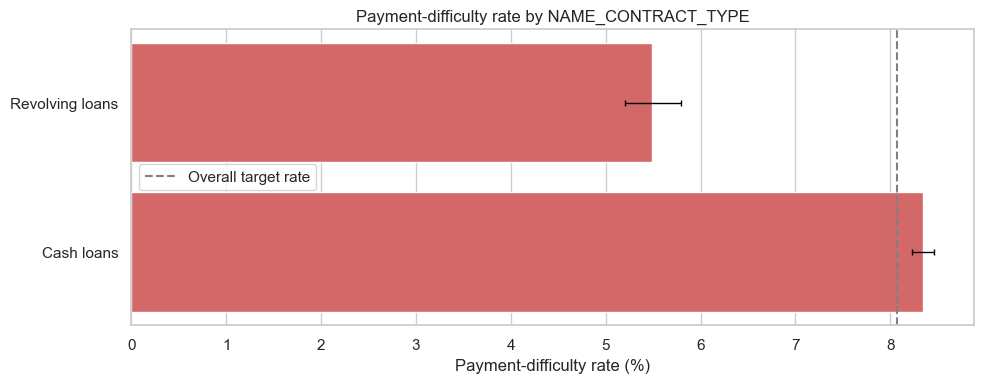

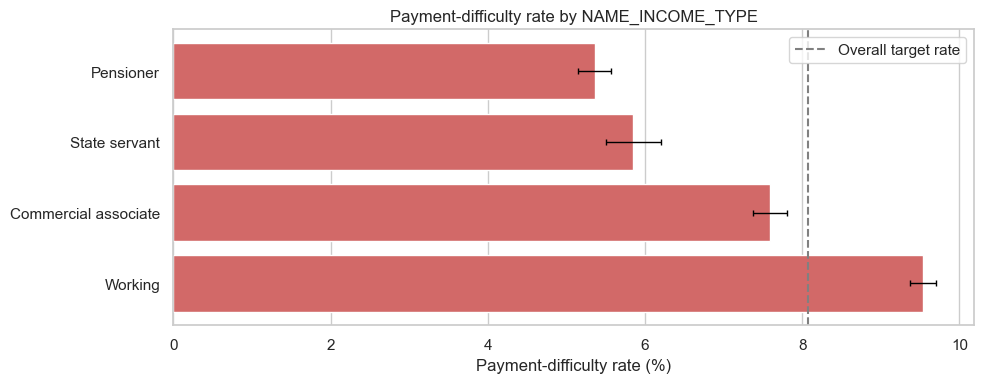

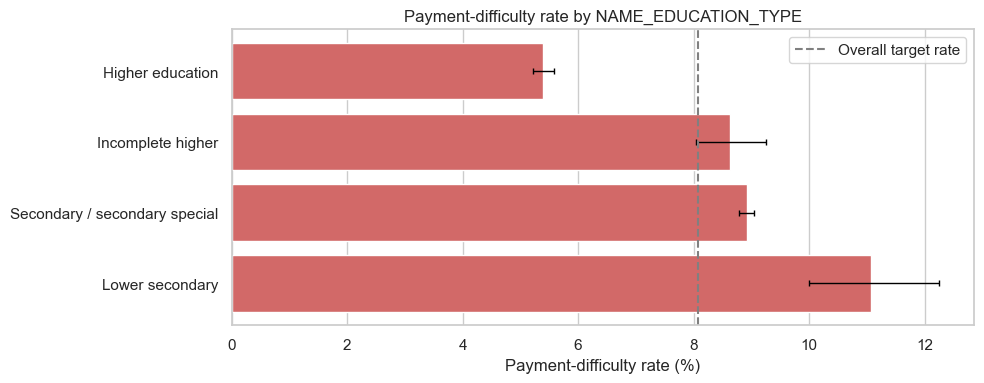

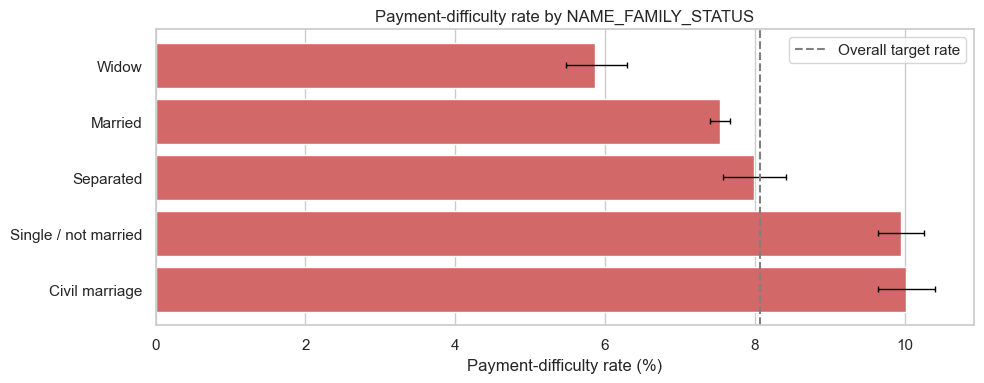

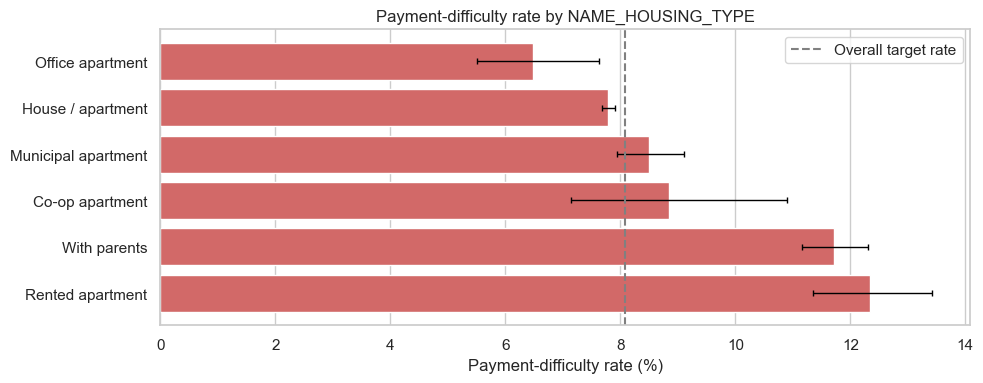

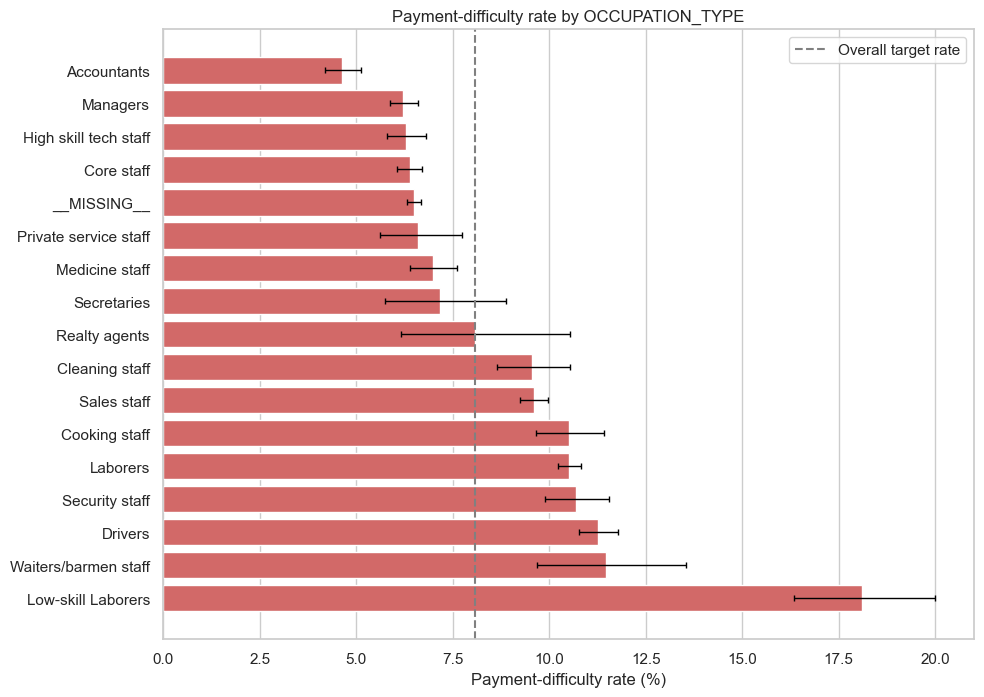

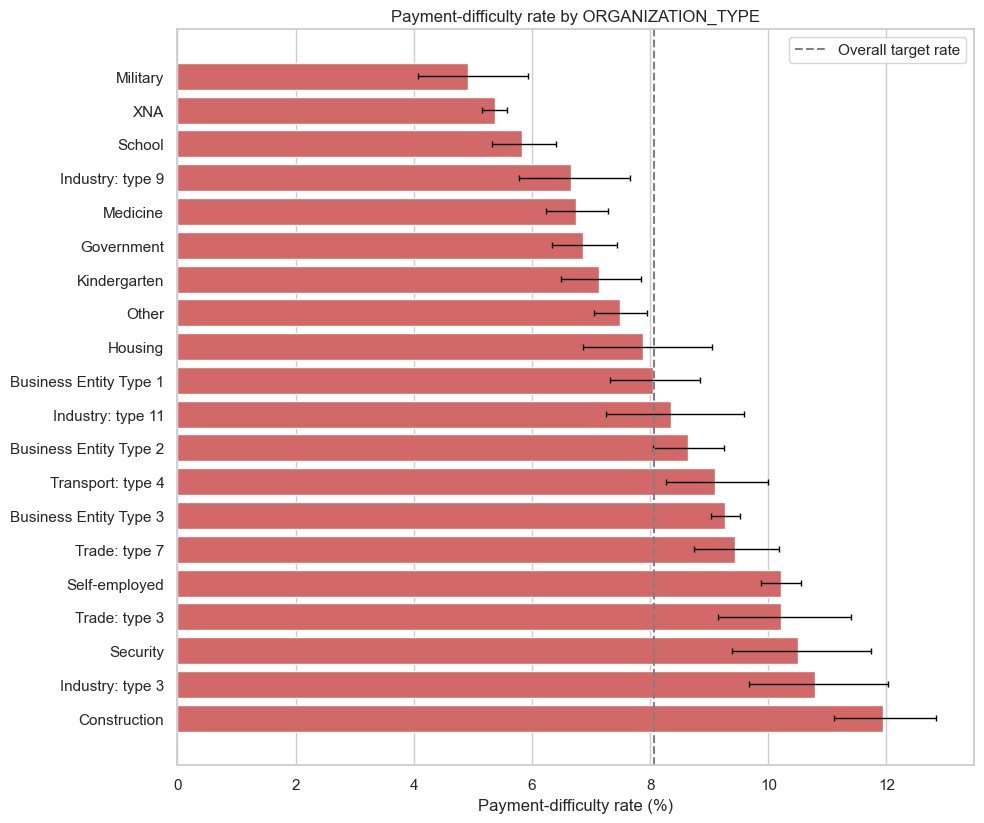

In [79]:
categorical_plot_features = [
    "NAME_CONTRACT_TYPE",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE",
]

for feature in categorical_plot_features:
    if feature in categorical_features:
        plot_categorical_target_rate(
            eda_df,
            feature,
        )

In [80]:
from scipy.stats import chi2_contingency


def bias_corrected_cramers_v(
    df: pd.DataFrame,
    feature: str,
    target: str = "TARGET",
    missing_label: str = "__MISSING__",
) -> float:
    feature_values = (
        df[feature]
        .astype("string")
        .fillna(missing_label)
    )

    contingency = pd.crosstab(
        feature_values,
        df[target],
    )

    if min(contingency.shape) < 2:
        return np.nan

    chi2 = chi2_contingency(
        contingency,
        correction=False,
    )[0]
    n = contingency.to_numpy().sum()
    n_rows, n_columns = contingency.shape

    phi_squared = chi2 / n
    phi_squared_corrected = max(
        0,
        phi_squared
        - (
            (n_columns - 1)
            * (n_rows - 1)
            / (n - 1)
        ),
    )
    rows_corrected = (
        n_rows
        - (n_rows - 1) ** 2 / (n - 1)
    )
    columns_corrected = (
        n_columns
        - (n_columns - 1) ** 2 / (n - 1)
    )
    denominator = min(
        rows_corrected - 1,
        columns_corrected - 1,
    )

    if denominator <= 0:
        return np.nan

    return np.sqrt(
        phi_squared_corrected
        / denominator
    )


categorical_association_records = []
overall_target_rate = eda_df["TARGET"].mean()

for feature in categorical_features:
    table = categorical_target_table(
        eda_df,
        feature,
    )
    reliable_table = table.loc[
        table["reliable_for_comparison"]
    ]

    weighted_abs_rate_deviation = np.average(
        np.abs(
            table["target_rate"]
            - overall_target_rate
        ),
        weights=table["application_count"],
    )

    categorical_association_records.append(
        {
            "feature": feature,
            "n_categories": len(table),
            "missing_pct": (
                eda_df[feature].isna().mean() * 100
            ),
            "cramers_v": bias_corrected_cramers_v(
                eda_df,
                feature,
            ),
            "weighted_abs_rate_deviation_pp": (
                weighted_abs_rate_deviation * 100
            ),
            "reliable_target_rate_range_pp": (
                reliable_table["target_rate_pct"].max()
                - reliable_table["target_rate_pct"].min()
                if len(reliable_table) >= 2
                else np.nan
            ),
        }
    )

categorical_association_summary = (
    pd.DataFrame(
        categorical_association_records
    )
    .sort_values(
        "cramers_v",
        ascending=False,
    )
    .reset_index(drop=True)
)

categorical_association_summary

,feature,n_categories,missing_pct,cramers_v,weighted_abs_rate_deviation_pp,reliable_target_rate_range_pp
0,OCCUPATION_TYPE,19,31.275,0.080,2.007,13.471
1,ORGANIZATION_TYPE,58,0.000,0.072,1.741,10.846
2,NAME_INCOME_TYPE,8,0.000,0.062,1.517,4.180
3,NAME_EDUCATION_TYPE,5,0.000,0.057,1.309,5.680
4,CODE_GENDER,3,0.000,0.055,1.411,3.134
5,WALLSMATERIAL_MODE,8,50.801,0.044,1.127,5.197
6,NAME_FAMILY_STATUS,6,0.000,0.042,0.930,4.145
7,EMERGENCYSTATE_MODE,3,47.389,0.042,1.138,2.448
8,HOUSETYPE_MODE,4,50.132,0.040,1.085,2.795
9,NAME_HOUSING_TYPE,6,0.000,0.037,0.523,5.856


In [81]:
RARE_CATEGORY_SHARE_THRESHOLD = 0.005

rare_category_records = []

for feature in categorical_features:
    values = (
        eda_df[feature]
        .astype("string")
        .fillna("__MISSING__")
    )
    counts = values.value_counts()
    shares = counts / len(eda_df)
    rare_mask = (
        shares
        < RARE_CATEGORY_SHARE_THRESHOLD
    )

    rare_category_records.append(
        {
            "feature": feature,
            "n_categories": len(counts),
            "n_rare_categories": rare_mask.sum(),
            "rare_observation_count": (
                counts.loc[rare_mask].sum()
            ),
            "rare_observation_share_pct": (
                shares.loc[rare_mask].sum()
                * 100
            ),
            "smallest_category_count": counts.min(),
        }
    )

rare_category_summary = (
    pd.DataFrame(rare_category_records)
    .sort_values(
        [
            "n_rare_categories",
            "rare_observation_share_pct",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

rare_category_summary

,feature,n_categories,n_rare_categories,rare_observation_count,rare_observation_share_pct,smallest_category_count
0,ORGANIZATION_TYPE,58,29,11677,4.747,19
1,OCCUPATION_TYPE,19,5,3554,1.445,424
2,NAME_INCOME_TYPE,8,4,40,0.016,3
3,NAME_TYPE_SUITE,8,3,1947,0.791,221
4,HOUSETYPE_MODE,4,2,2202,0.895,993
5,NAME_HOUSING_TYPE,6,1,882,0.359,882
6,NAME_EDUCATION_TYPE,5,1,124,0.050,124
7,CODE_GENDER,3,1,2,0.001,2
8,NAME_FAMILY_STATUS,6,1,2,0.001,2
9,NAME_CONTRACT_TYPE,2,0,0,0.000,23448


In [82]:
occupation_missing_by_income = pd.crosstab(
    eda_df["NAME_INCOME_TYPE"]
    .astype("string")
    .fillna("__MISSING__"),
    eda_df["OCCUPATION_TYPE"].isna().map(
        {
            False: "Occupation observed",
            True: "Occupation missing",
        }
    ),
    normalize="columns",
).mul(100).round(2)

occupation_missing_by_income

OCCUPATION_TYPE,Occupation missing,Occupation observed
NAME_INCOME_TYPE,,
Businessman,0.000,0.000
Commercial associate,12.830,28.040
Maternity leave,0.000,0.000
Pensioner,57.360,0.000
State servant,3.900,8.590
Student,0.000,0.010
Unemployed,0.020,0.000
Working,25.890,63.360


In [83]:
structured_category_rows = []

for feature in categorical_features:
    table = categorical_target_table(
        eda_df,
        feature,
    )
    selected = table.loc[
        table["category"].isin(
            [
                "__MISSING__",
                "XNA",
                "Unknown",
            ]
        )
    ].copy()

    if not selected.empty:
        selected.insert(
            0,
            "feature",
            feature,
        )
        structured_category_rows.append(
            selected
        )

structured_category_summary = (
    pd.concat(
        structured_category_rows,
        ignore_index=True,
    )
    if structured_category_rows
    else pd.DataFrame()
)

structured_category_summary

,feature,category,application_count,target_count,target_rate,application_share_pct,target_rate_pct,lift_vs_overall,wilson_lower_pct,wilson_upper_pct,reliable_for_comparison
0,CODE_GENDER,XNA,2,0,0.000,0.001,0.000,0.000,0.000,65.763,False
1,NAME_TYPE_SUITE,__MISSING__,1029,57,0.055,0.418,5.539,0.686,4.300,7.110,True
2,NAME_FAMILY_STATUS,Unknown,2,0,0.000,0.001,0.000,0.000,0.000,65.763,False
3,OCCUPATION_TYPE,__MISSING__,76940,4995,0.065,31.275,6.492,0.804,6.320,6.668,True
4,ORGANIZATION_TYPE,XNA,44143,2370,0.054,17.944,5.369,0.665,5.162,5.583,True
5,FONDKAPREMONT_MODE,__MISSING__,168215,14464,0.086,68.378,8.599,1.065,8.465,8.733,True
6,HOUSETYPE_MODE,__MISSING__,123328,11269,0.091,50.132,9.137,1.132,8.978,9.300,True
7,WALLSMATERIAL_MODE,__MISSING__,124975,11394,0.091,50.801,9.117,1.129,8.959,9.278,True
8,EMERGENCYSTATE_MODE,__MISSING__,116581,10786,0.093,47.389,9.252,1.146,9.087,9.420,True


## Categorical-feature findings

- The development data contain 16 categorical predictors. Their cardinality
  ranges from 2 categories to 58 categories when missing values are treated as
  an explicit level. `ORGANIZATION_TYPE` has the highest cardinality, followed
  by `OCCUPATION_TYPE`.

- Univariate associations between categorical predictors and payment difficulty
  are generally weak. The largest bias-corrected Cramér's V is observed for
  `OCCUPATION_TYPE` (`0.080`), followed by `ORGANIZATION_TYPE` (`0.072`),
  `NAME_INCOME_TYPE` (`0.062`) and `NAME_EDUCATION_TYPE` (`0.057`). These
  values indicate association, not causality or incremental predictive value.

- Income type shows meaningful descriptive differences. The target rate is
  9.54% for working applicants, 7.59% for commercial associates, 5.85% for
  state servants and 5.36% for pensioners. The 29.41% rate observed for
  unemployed applicants is based on only 17 observations and is therefore
  unreliable.

- Education level is also associated with payment difficulty. The target rate
  is 11.07% for applicants with lower-secondary education, 8.92% for those
  with secondary education and 5.39% for those with higher education. The
  academic-degree group contains only 124 observations and should not be
  interpreted independently.

- Among occupations with sufficient support, low-skill laborers have the
  highest observed target rate (`18.10%`), whereas accountants have one of the
  lowest (`4.63%`). These differences may partly reflect income, age and
  employment characteristics and should not be interpreted as isolated
  occupational effects.

- Missing categorical values are structured rather than random.
  `OCCUPATION_TYPE` is missing for 31.28% of applications and its missing group
  has a target rate of 6.49%, below the overall development-set rate of
  approximately 8.07%. Pensioners account for 57.36% of all applications with
  missing occupation information.

- Missing housing-related categories exhibit target rates between approximately
  8.60% and 9.25%. Their missingness should therefore be preserved explicitly
  or represented through missing indicators rather than removed automatically.

- `ORGANIZATION_TYPE = XNA` affects 17.94% of applications and has a target rate
  of 5.37%. Its frequency and target rate closely resemble the anomalous
  `DAYS_EMPLOYED = 365243` group, suggesting that it represents a structured
  applicant profile rather than an ordinary data-entry error. In contrast,
  `CODE_GENDER = XNA` and `NAME_FAMILY_STATUS = Unknown` each contain only two
  observations and cannot be interpreted separately.

- Using a 0.5% frequency threshold, `ORGANIZATION_TYPE` contains 29 rare
  categories representing 4.75% of applications. Rare-category grouping may
  improve stability, but the grouping rule must be learned from each training
  fold rather than from the complete dataset.

- Categorical missing-value handling, rare-category grouping and encoding must
  be fitted inside the modeling pipeline. If target or WOE encoding is tested,
  it must be generated out-of-fold to prevent target leakage.

# EDA synthesis and preprocessing decisions

This section consolidates the exploratory findings into an auditable
preprocessing plan. It reviews feature health, global numerical redundancy and
model-specific transformations without fitting a predictive model.

All decisions remain provisional until they are evaluated through
cross-validation. The final test set remains untouched.

In [84]:
eda_model_feature_df = ratio_eda_df.copy()

non_predictor_features = [
    "SK_ID_CURR",
    "TARGET",
]

candidate_predictors = [
    feature
    for feature in eda_model_feature_df.columns
    if feature not in non_predictor_features
]

candidate_categorical_features = [
    feature
    for feature in candidate_predictors
    if (
        pd.api.types.is_object_dtype(
            eda_model_feature_df[feature]
        )
        or isinstance(
            eda_model_feature_df[feature].dtype,
            pd.CategoricalDtype,
        )
    )
]

candidate_numerical_features = [
    feature
    for feature in candidate_predictors
    if feature not in candidate_categorical_features
]

feature_inventory = pd.Series(
    {
        "candidate_predictor_count": len(
            candidate_predictors
        ),
        "numerical_predictor_count": len(
            candidate_numerical_features
        ),
        "categorical_predictor_count": len(
            candidate_categorical_features
        ),
        "identifier_count": 1,
        "target_count": 1,
    },
    name="count",
)

feature_inventory

candidate_predictor_count      134
numerical_predictor_count      118
categorical_predictor_count     16
identifier_count                 1
target_count                     1
Name: count, dtype: int64

In [85]:
def feature_health_profile(
    df: pd.DataFrame,
    features: list[str],
) -> pd.DataFrame:
    records = []

    for feature in features:
        series = df[feature]
        counts = series.value_counts(
            dropna=False,
            normalize=True,
        )

        n_unique_observed = series.nunique(
            dropna=True
        )
        n_unique_including_missing = series.nunique(
            dropna=False
        )
        most_frequent_share_pct = (
            counts.iloc[0] * 100
        )

        feature_kind = (
            "categorical"
            if feature
            in candidate_categorical_features
            else "numerical"
        )

        records.append(
            {
                "feature": feature,
                "feature_kind": feature_kind,
                "dtype": str(series.dtype),
                "missing_pct": (
                    series.isna().mean() * 100
                ),
                "n_unique_observed": (
                    n_unique_observed
                ),
                "n_unique_including_missing": (
                    n_unique_including_missing
                ),
                "most_frequent_share_pct": (
                    most_frequent_share_pct
                ),
                "is_constant": (
                    n_unique_observed <= 1
                ),
                "is_near_constant": (
                    most_frequent_share_pct >= 99.5
                ),
                "has_high_missingness": (
                    series.isna().mean() >= 0.60
                ),
                "is_high_cardinality_categorical": (
                    feature_kind == "categorical"
                    and n_unique_observed >= 50
                ),
            }
        )

    return pd.DataFrame(records)


feature_health_summary = feature_health_profile(
    eda_model_feature_df,
    candidate_predictors,
)

feature_health_issues = (
    feature_health_summary.loc[
        feature_health_summary[
            [
                "is_constant",
                "is_near_constant",
                "has_high_missingness",
                "is_high_cardinality_categorical",
            ]
        ].any(axis=1)
    ]
    .sort_values(
        [
            "is_constant",
            "is_near_constant",
            "has_high_missingness",
            "missing_pct",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

feature_health_issues

,feature,feature_kind,dtype,missing_pct,n_unique_observed,n_unique_including_missing,most_frequent_share_pct,is_constant,is_near_constant,has_high_missingness,is_high_cardinality_categorical
0,FLAG_MOBIL,numerical,int64,0.000,2,2,100.000,False,True,False,False
1,FLAG_CONT_MOBILE,numerical,int64,0.000,2,2,99.812,False,True,False,False
2,FLAG_DOCUMENT_2,numerical,int64,0.000,2,2,99.996,False,True,False,False
3,FLAG_DOCUMENT_4,numerical,int64,0.000,2,2,99.991,False,True,False,False
4,FLAG_DOCUMENT_7,numerical,int64,0.000,2,2,99.981,False,True,False,False
5,FLAG_DOCUMENT_9,numerical,int64,0.000,2,2,99.615,False,True,False,False
6,FLAG_DOCUMENT_10,numerical,int64,0.000,2,2,99.998,False,True,False,False
7,FLAG_DOCUMENT_11,numerical,int64,0.000,2,2,99.613,False,True,False,False
8,FLAG_DOCUMENT_12,numerical,int64,0.000,2,2,100.000,False,True,False,False
9,FLAG_DOCUMENT_13,numerical,int64,0.000,2,2,99.662,False,True,False,False


In [87]:
CORRELATION_SAMPLE_SIZE = 50_000
STRONG_CORRELATION_THRESHOLD = 0.90

numeric_redundancy_features = [
    feature
    for feature in candidate_numerical_features
    if (
        eda_model_feature_df[feature]
        .nunique(dropna=True)
        > 1
    )
]

correlation_sample = (
    eda_model_feature_df[
        numeric_redundancy_features
    ]
    .sample(
        n=min(
            CORRELATION_SAMPLE_SIZE,
            len(eda_model_feature_df),
        ),
        random_state=RANDOM_STATE,
    )
)

global_spearman_correlation = (
    correlation_sample.corr(
        method="spearman",
        min_periods=1_000,
    )
)

global_upper_triangle = (
    global_spearman_correlation
    .where(
        np.triu(
            np.ones(
                global_spearman_correlation.shape,
                dtype=bool,
            ),
            k=1,
        )
    )
    .stack()
    .rename("spearman_correlation")
    .reset_index()
    .rename(
        columns={
            "level_0": "feature_1",
            "level_1": "feature_2",
        }
    )
)

global_strong_correlation_pairs = (
    global_upper_triangle
    .assign(
        absolute_correlation=lambda df: (
            df["spearman_correlation"].abs()
        )
    )
    .query(
        "absolute_correlation "
        ">= @STRONG_CORRELATION_THRESHOLD"
    )
    .sort_values(
        "absolute_correlation",
        ascending=False,
    )
    .reset_index(drop=True)
)

global_strong_correlation_pairs[
    "paired_non_missing_count"
] = [
    correlation_sample[
        [feature_1, feature_2]
    ].dropna().shape[0]
    for feature_1, feature_2 in zip(
        global_strong_correlation_pairs[
            "feature_1"
        ],
        global_strong_correlation_pairs[
            "feature_2"
        ],
    )
]

global_strong_correlation_pairs

,feature_1,feature_2,spearman_correlation,absolute_correlation,paired_non_missing_count
0,ANNUITY_CREDIT_RATIO,CREDIT_TERM_PROXY,-1.000,1.000,49998
1,DAYS_EMPLOYED,EMPLOYMENT_YEARS,-1.000,1.000,41079
2,DAYS_REGISTRATION,REGISTRATION_YEARS,-1.000,1.000,50000
3,DAYS_ID_PUBLISH,ID_PUBLISH_YEARS,-1.000,1.000,50000
4,DAYS_BIRTH,AGE_YEARS,-1.000,1.000,50000
5,FLAG_EMP_PHONE,DAYS_EMPLOYED_ANOMALOUS,-1.000,1.000,50000
6,YEARS_BUILD_AVG,YEARS_BUILD_MEDI,0.998,0.998,16709
7,YEARS_BEGINEXPLUATATION_AVG,YEARS_BEGINEXPLUATATION_MEDI,0.997,0.997,25531
8,OBS_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,0.997,0.997,49824
9,FLOORSMIN_AVG,FLOORSMIN_MEDI,0.997,0.997,15976


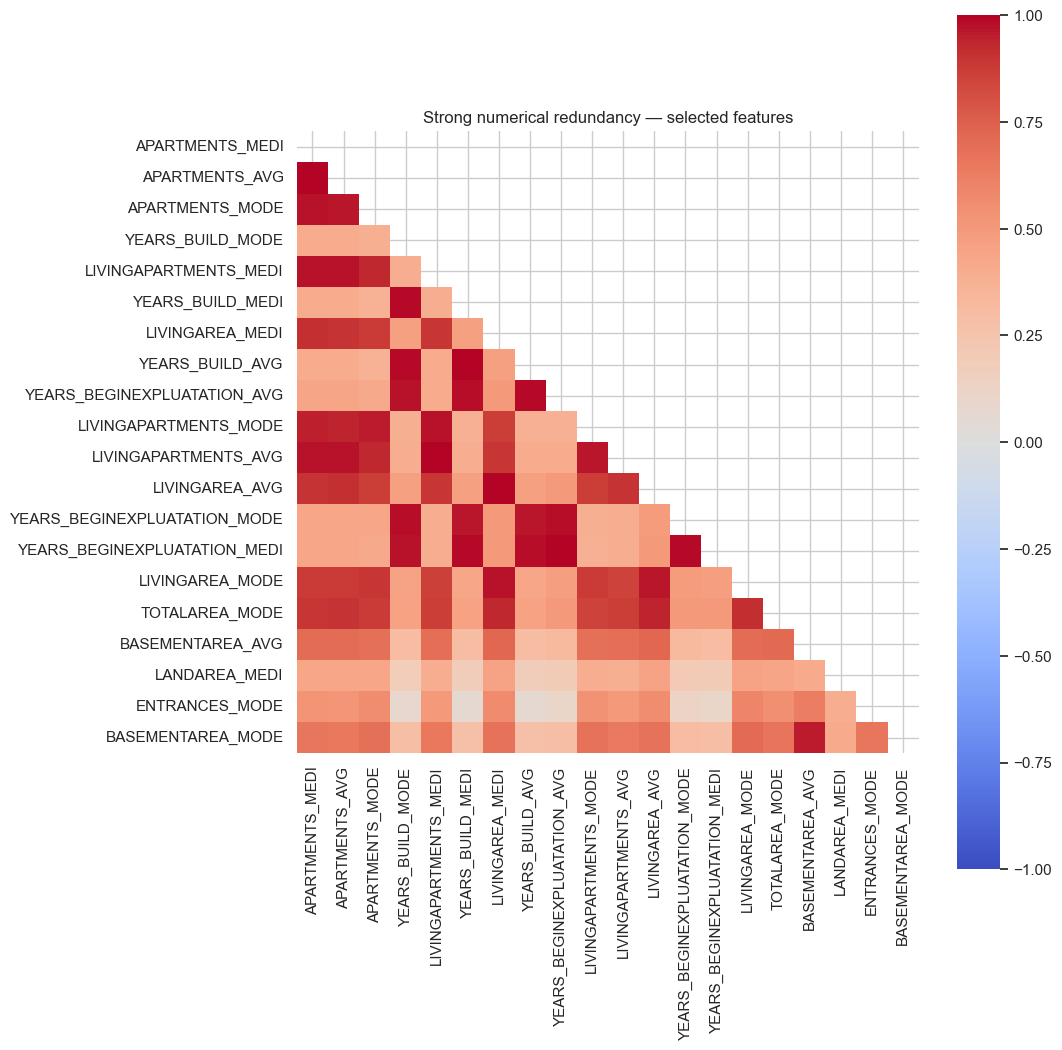

In [88]:
strong_feature_frequency = pd.concat(
    [
        global_strong_correlation_pairs[
            "feature_1"
        ],
        global_strong_correlation_pairs[
            "feature_2"
        ],
    ],
    ignore_index=True,
).value_counts()

selected_redundancy_features = (
    strong_feature_frequency
    .head(20)
    .index
    .tolist()
)

if len(selected_redundancy_features) >= 2:
    selected_correlation = (
        global_spearman_correlation.loc[
            selected_redundancy_features,
            selected_redundancy_features,
        ]
    )

    fig_size = max(
        8,
        0.55 * len(
            selected_redundancy_features
        ),
    )

    fig, ax = plt.subplots(
        figsize=(fig_size, fig_size)
    )

    sns.heatmap(
        selected_correlation,
        mask=np.triu(
            np.ones_like(
                selected_correlation,
                dtype=bool,
            )
        ),
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        ax=ax,
    )

    ax.set_title(
        "Strong numerical redundancy — "
        "selected features"
    )

    plt.tight_layout()
    plt.show()

In [89]:
redundancy_decision_table = pd.DataFrame(
    [
        {
            "feature_group": "Applicant age",
            "retain": "AGE_YEARS",
            "exclude_or_compare": "DAYS_BIRTH",
            "reason": (
                "AGE_YEARS is an interpretable deterministic "
                "transformation of DAYS_BIRTH."
            ),
        },
        {
            "feature_group": "Employment duration",
            "retain": (
                "EMPLOYMENT_YEARS + "
                "DAYS_EMPLOYED_ANOMALOUS"
            ),
            "exclude_or_compare": "DAYS_EMPLOYED",
            "reason": (
                "The raw variable contains the 365243 sentinel; "
                "duration and anomaly should be represented separately."
            ),
        },
        {
            "feature_group": "Registration recency",
            "retain": "REGISTRATION_YEARS",
            "exclude_or_compare": "DAYS_REGISTRATION",
            "reason": (
                "The two features contain the same information "
                "with opposite scale."
            ),
        },
        {
            "feature_group": "Identity-document recency",
            "retain": "ID_PUBLISH_YEARS",
            "exclude_or_compare": "DAYS_ID_PUBLISH",
            "reason": (
                "The engineered feature has a clearer semantic "
                "interpretation."
            ),
        },
        {
            "feature_group": "Credit payment structure",
            "retain": "CREDIT_TERM_PROXY",
            "exclude_or_compare": "ANNUITY_CREDIT_RATIO",
            "reason": (
                "They are exact monotonic inverses. "
                "CREDIT_TERM_PROXY has the larger univariate SMD."
            ),
        },
        {
            "feature_group": "Credit, goods and annuity amounts",
            "retain": (
                "Raw amounts and selected ratios initially"
            ),
            "exclude_or_compare": (
                "Evaluate removal through cross-validation"
            ),
            "reason": (
                "The variables are strongly correlated but have "
                "different business interpretations."
            ),
        },
        {
            "feature_group": "External scores",
            "retain": (
                "EXT_SOURCE_1/2/3 + "
                "EXT_SOURCE_AVAILABLE_COUNT"
            ),
            "exclude_or_compare": (
                "Run an ablation without EXT_SOURCE features"
            ),
            "reason": (
                "They are highly predictive, but availability "
                "and production-time validity must be confirmed."
            ),
        },
    ]
)

redundancy_decision_table

,feature_group,retain,exclude_or_compare,reason
0,Applicant age,AGE_YEARS,DAYS_BIRTH,AGE_YEARS is an interpretable deterministic tr...
1,Employment duration,EMPLOYMENT_YEARS + DAYS_EMPLOYED_ANOMALOUS,DAYS_EMPLOYED,The raw variable contains the 365243 sentinel;...
2,Registration recency,REGISTRATION_YEARS,DAYS_REGISTRATION,The two features contain the same information ...
3,Identity-document recency,ID_PUBLISH_YEARS,DAYS_ID_PUBLISH,The engineered feature has a clearer semantic ...
4,Credit payment structure,CREDIT_TERM_PROXY,ANNUITY_CREDIT_RATIO,They are exact monotonic inverses. CREDIT_TERM...
5,"Credit, goods and annuity amounts",Raw amounts and selected ratios initially,Evaluate removal through cross-validation,The variables are strongly correlated but have...
6,External scores,EXT_SOURCE_1/2/3 + EXT_SOURCE_AVAILABLE_COUNT,Run an ablation without EXT_SOURCE features,"They are highly predictive, but availability a..."


In [90]:
preprocessing_decision_table = pd.DataFrame(
    [
        {
            "feature_scope": "Identifier",
            "issue": "SK_ID_CURR is not a predictor",
            "proposed_action": (
                "Exclude from X; retain separately "
                "for traceability"
            ),
            "validation": "Schema test",
        },
        {
            "feature_scope": "Numerical missing values",
            "issue": "Missingness is structured",
            "proposed_action": (
                "Median imputation; test missing indicators "
                "for informative variables"
            ),
            "validation": "Cross-validation",
        },
        {
            "feature_scope": "Categorical missing values",
            "issue": "Missing is often informative",
            "proposed_action": (
                "Represent missing as an explicit category"
            ),
            "validation": "Cross-validation",
        },
        {
            "feature_scope": "DAYS_EMPLOYED",
            "issue": "Sentinel value 365243",
            "proposed_action": (
                "Replace sentinel with missing and create "
                "DAYS_EMPLOYED_ANOMALOUS"
            ),
            "validation": "Unit test",
        },
        {
            "feature_scope": "Skewed amounts",
            "issue": "Strong right skew and extreme values",
            "proposed_action": (
                "Evaluate log1p for linear models; "
                "do not remove extremes automatically"
            ),
            "validation": "Cross-validation",
        },
        {
            "feature_scope": "Categorical predictors",
            "issue": "Unknown categories at inference",
            "proposed_action": (
                "One-hot encoding with handle_unknown='ignore' "
                "for the linear baseline"
            ),
            "validation": "Pipeline test",
        },
        {
            "feature_scope": "Rare categorical levels",
            "issue": "Unstable estimates",
            "proposed_action": (
                "Evaluate grouping levels below 0.5%; "
                "learn groups only on training folds"
            ),
            "validation": "Cross-validation",
        },
        {
            "feature_scope": "Target or WOE encoding",
            "issue": "High target-leakage risk",
            "proposed_action": (
                "Use only out-of-fold encoding if evaluated"
            ),
            "validation": "Leakage test",
        },
        {
            "feature_scope": "Financial ratios",
            "issue": "Invalid denominators and infinities",
            "proposed_action": (
                "Use safe_divide and reproduce definitions "
                "inside feature engineering"
            ),
            "validation": "Unit test",
        },
        {
            "feature_scope": "Correlated predictors",
            "issue": "Coefficient instability",
            "proposed_action": (
                "Remove deterministic duplicates and use "
                "regularization for the logistic baseline"
            ),
            "validation": "Cross-validation",
        },
        {
            "feature_scope": "Numerical scale",
            "issue": "Features have very different scales",
            "proposed_action": (
                "Standardize after imputation for logistic "
                "regression; scaling is optional for trees"
            ),
            "validation": "Pipeline test",
        },
        {
            "feature_scope": "Class imbalance",
            "issue": "TARGET=1 represents about 8.07%",
            "proposed_action": (
                "Use stratified folds; compare class weights "
                "inside training only"
            ),
            "validation": (
                "ROC-AUC, PR-AUC, recall and calibration"
            ),
        },
    ]
)

preprocessing_decision_table

,feature_scope,issue,proposed_action,validation
0,Identifier,SK_ID_CURR is not a predictor,Exclude from X; retain separately for traceabi...,Schema test
1,Numerical missing values,Missingness is structured,Median imputation; test missing indicators for...,Cross-validation
2,Categorical missing values,Missing is often informative,Represent missing as an explicit category,Cross-validation
3,DAYS_EMPLOYED,Sentinel value 365243,Replace sentinel with missing and create DAYS_...,Unit test
4,Skewed amounts,Strong right skew and extreme values,Evaluate log1p for linear models; do not remov...,Cross-validation
5,Categorical predictors,Unknown categories at inference,One-hot encoding with handle_unknown='ignore' ...,Pipeline test
6,Rare categorical levels,Unstable estimates,Evaluate grouping levels below 0.5%; learn gro...,Cross-validation
7,Target or WOE encoding,High target-leakage risk,Use only out-of-fold encoding if evaluated,Leakage test
8,Financial ratios,Invalid denominators and infinities,Use safe_divide and reproduce definitions insi...,Unit test
9,Correlated predictors,Coefficient instability,Remove deterministic duplicates and use regula...,Cross-validation


In [91]:
engineered_features_to_validate = [
    "AGE_YEARS",
    "EMPLOYMENT_YEARS",
    "REGISTRATION_YEARS",
    "ID_PUBLISH_YEARS",
    "DAYS_EMPLOYED_ANOMALOUS",
    "EXT_SOURCE_AVAILABLE_COUNT",
    *ratio_features,
]

engineered_features_to_validate = [
    feature
    for feature in engineered_features_to_validate
    if feature in eda_model_feature_df.columns
]

engineered_numeric_values = (
    eda_model_feature_df[
        engineered_features_to_validate
    ]
    .select_dtypes(include=np.number)
)

infinite_engineered_value_count = (
    np.isinf(
        engineered_numeric_values.to_numpy(
            dtype=float
        )
    ).sum()
)

eda_validation_checks = pd.Series(
    {
        "target_excluded_from_predictors": (
            "TARGET" not in candidate_predictors
        ),
        "identifier_excluded_from_predictors": (
            "SK_ID_CURR"
            not in candidate_predictors
        ),
        "candidate_predictors_are_unique": (
            len(candidate_predictors)
            == len(set(candidate_predictors))
        ),
        "no_infinite_engineered_values": (
            infinite_engineered_value_count == 0
        ),
        "development_target_is_complete": (
            development_df["TARGET"]
            .notna()
            .all()
        ),
        "development_and_final_test_ids_disjoint": (
            set(
                development_df["SK_ID_CURR"]
            ).isdisjoint(
                set(
                    final_test_df["SK_ID_CURR"]
                )
            )
        ),
        "split_row_counts_reconcile": (
            len(development_df)
            + len(final_test_df)
            == len(application)
        ),
    },
    name="passed",
)

eda_validation_checks

target_excluded_from_predictors            True
identifier_excluded_from_predictors        True
candidate_predictors_are_unique            True
no_infinite_engineered_values              True
development_target_is_complete             True
development_and_final_test_ids_disjoint    True
split_row_counts_reconcile                 True
Name: passed, dtype: bool

In [95]:
eda_tables = {
    "target_summary": target_summary,
    "missing_summary": missing_summary,
    "reliable_missing_target_report": (
        reliable_missing_report
    ),
    "numerical_effect_size_summary": (
        effect_size_summary
    ),
    "ratio_effect_size_summary": (
        ratio_effect_size
    ),
    "categorical_association_summary": (
        categorical_association_summary
    ),
    "rare_category_summary": (
        rare_category_summary
    ),
    "redundancy_decisions": (
        redundancy_decision_table
    ),
    "preprocessing_decisions": (
        preprocessing_decision_table
    ),
}

for table_name, table in eda_tables.items():
    table.to_csv(
        TABLE_DIR / f"{table_name}.csv",
        index=True,
    )

print(
    f"EDA tables exported to: "
    f"{TABLE_DIR.resolve()}"
)

EDA tables exported to: C:\Users\manhh\Documents\home-credit-risk-scoring\reports\tables


## 6. EDA synthesis and preprocessing decisions

- The final test set has remained isolated throughout target-based EDA. All
  preprocessing choices and hyperparameters must be selected using only the
  development data and its training folds.

- Payment difficulty affects approximately 8.07% of development applications.
  Accuracy is therefore not an appropriate primary model-selection metric.
  Evaluation should include ROC-AUC, PR-AUC, recall at business-relevant
  thresholds and probability calibration.

- The external scores provide the strongest univariate numerical separation,
  followed by applicant age and employment history. Because their exact
  definitions and production-time availability are not fully documented, an
  ablation study with and without the `EXT_SOURCE_*` variables is required.

- Several numerical relationships are nonlinear. Financial ratios and quantile
  analyses reveal patterns that would not be adequately represented by a
  purely linear specification without transformations, splines or interaction
  terms.

- Categorical predictors have individually weak associations with the target,
  although occupations, organization type, income type and education exhibit
  meaningful descriptive variation. Rare categories and small groups must not
  be interpreted without considering their uncertainty.

- Missingness is structured across both numerical and categorical features.
  Missing values should not be removed indiscriminately. Imputation, explicit
  missing categories and selected missing indicators must be evaluated inside
  the preprocessing pipeline.

- Deterministic transformations and exact inverse features should not be
  included simultaneously in an interpretable linear baseline. Other correlated
  financial variables may initially be retained and evaluated through
  regularization and cross-validation.

- The next notebook should implement feature engineering and preprocessing as
  reusable transformations. Any imputation statistics, category grouping,
  scaling or target-dependent encoding must be learned exclusively from each
  training fold to prevent leakage.